In [1]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.impute import SimpleImputer
import os
from scipy.stats import zscore

## BMI 

Original dataset shape: (1439696, 216)
Subset shape before NaN handling: (1439696, 8)
Subset shape after NaN replacement: (1439696, 8)
Subset shape after index reset: (1439696, 8)

Summary Statistics for Selected Columns:
              _BMI5      _BMI5CAT       _RFBMI5       WEIGHT2         WTKG3  \
count  1.348949e+06  1.348949e+06  1.439696e+06  1.366618e+06  1.366602e+06   
mean   2.783243e+03  2.919372e+00  2.112488e+00  1.919078e+02  8.010709e+03   
std    6.265441e+02  8.267934e-01  1.845171e+00  3.715695e+02  2.052155e+03   
min    1.202000e+03  1.000000e+00  1.000000e+00  5.000000e+01  2.268000e+03   
25%    2.367000e+03  2.000000e+00  1.000000e+00  1.450000e+02  6.577000e+03   
50%    2.663000e+03  3.000000e+00  2.000000e+00  1.700000e+02  7.711000e+03   
75%    3.079000e+03  4.000000e+00  2.000000e+00  2.000000e+02  9.072000e+03   
max    9.995000e+03  4.000000e+00  9.000000e+00  9.501000e+03  2.903000e+04   

            HEIGHT3          HTM4         HTIN4  
count  1.409645e

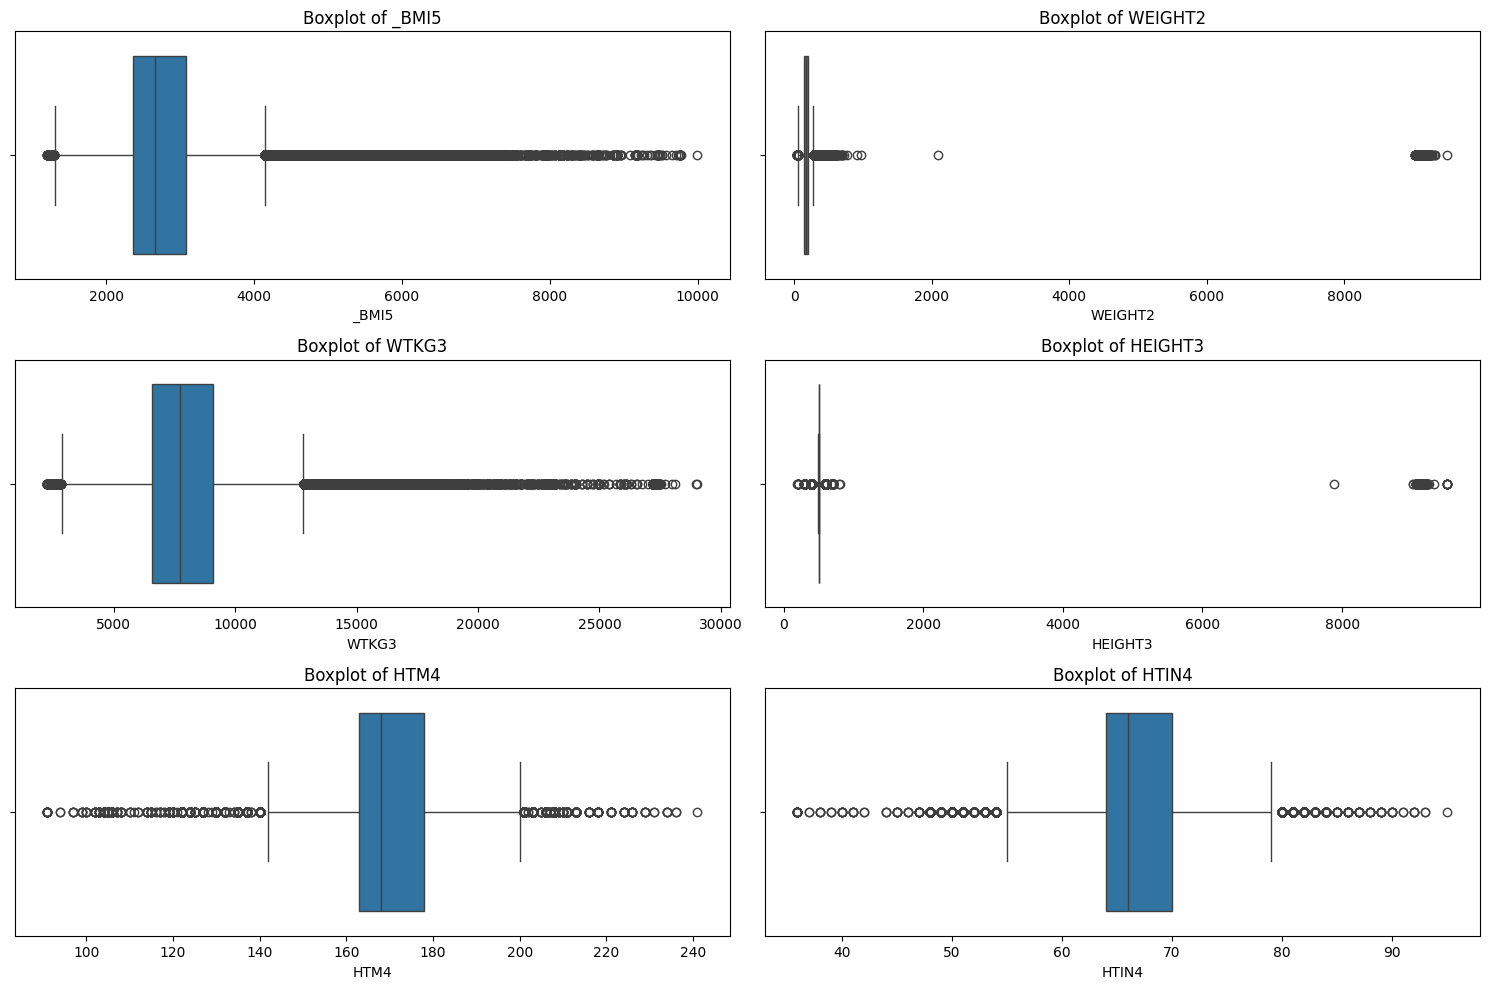

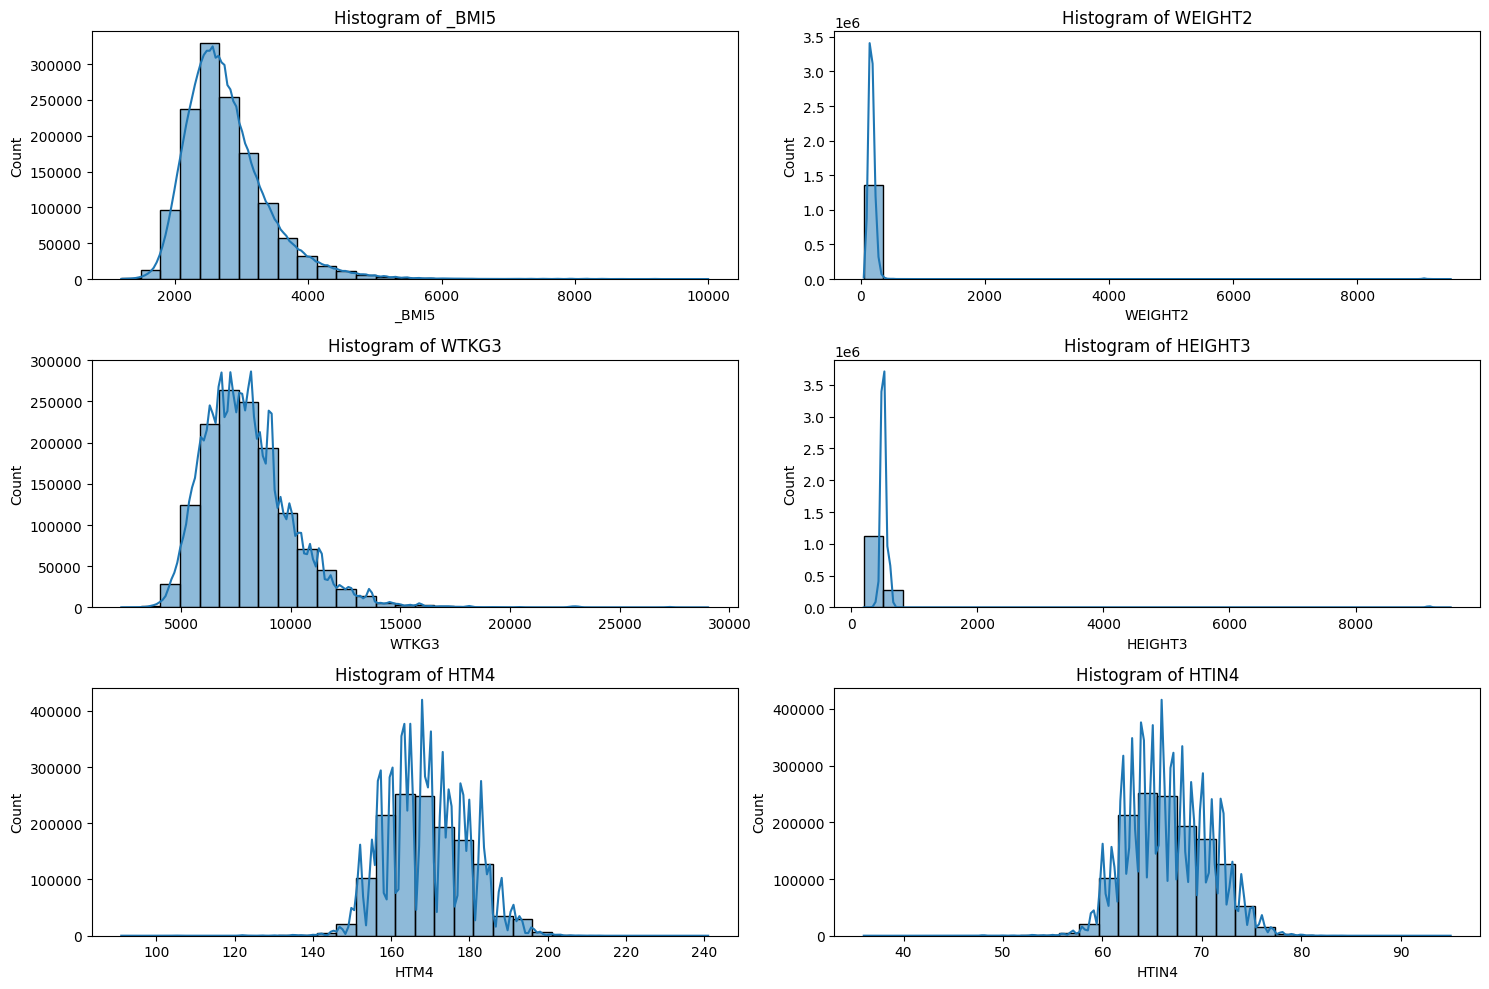

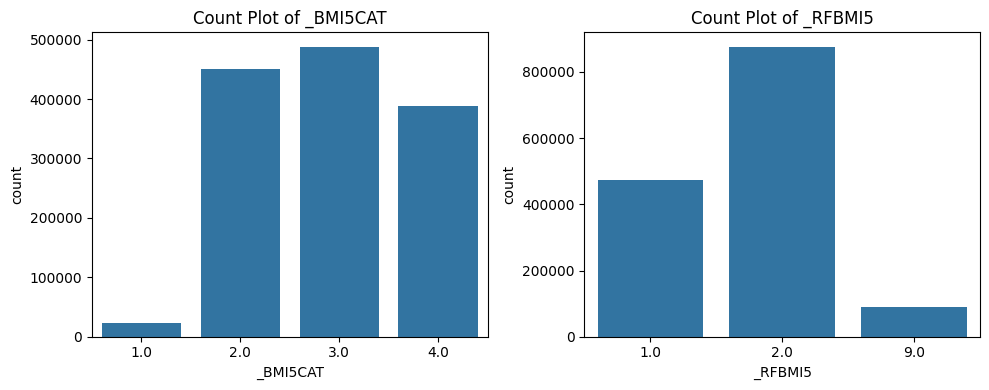

In [2]:
df_cleaned = pd.read_csv('../data/raw/Behavioral_Risk_Factor_Surveillance_2011_2013_2015.csv')
print(f"Original dataset shape: {df_cleaned.shape}")

# Columns to analyze for outliers
columns = ['_BMI5', '_BMI5CAT', '_RFBMI5', 'WEIGHT2', 'WTKG3', 'HEIGHT3', 'HTM4', 'HTIN4']

# Subset the dataset to these columns
df_subset = df_cleaned[columns].copy()
print(f"Subset shape before NaN handling: {df_subset.shape}")

# Step 1: Handle BRFSS-specific codes (e.g., 7777, 9999 for "don't know"/"refused")
# Replace common BRFSS codes with NaN for numerical columns
num_columns = ['_BMI5', 'WEIGHT2', 'WTKG3', 'HEIGHT3', 'HTM4', 'HTIN4']
df_subset[num_columns] = df_subset[num_columns].replace([777, 7777, 999, 9999], np.nan)
print(f"Subset shape after NaN replacement: {df_subset.shape}")

# Reset index to avoid misalignment
df_subset = df_subset.reset_index(drop=True)
print(f"Subset shape after index reset: {df_subset.shape}")

# Step 2: Summary statistics
print("\nSummary Statistics for Selected Columns:")
print(df_subset.describe(include='all'))

# Step 3: Detect outliers using IQR and Z-score
def detect_outliers_iqr(data, column):
    """Detect outliers using IQR method."""
    # Drop NaNs for this column to avoid issues in quantile calculation
    valid_data = data[column].dropna()
    Q1 = valid_data.quantile(0.25)
    Q3 = valid_data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    # Create boolean mask for outliers
    mask = (data[column] < lower_bound) | (data[column] > upper_bound)
    # Apply mask, ensuring NaNs are preserved
    outliers = data.loc[mask, column]
    return len(outliers), lower_bound, upper_bound

def detect_outliers_zscore(data, column, threshold=3):
    """Detect outliers using Z-score method."""
    valid_data = data[column].dropna()
    z_scores = zscore(valid_data)
    # Create mask for valid data
    mask = np.abs(z_scores) > threshold
    outliers = valid_data[mask]
    return len(outliers)

# Print outlier counts
print("\nOutlier Counts (IQR and Z-score):")
for col in num_columns:
    if df_subset[col].notna().sum() > 0:  # Check if column has non-null values
        iqr_count, lower, upper = detect_outliers_iqr(df_subset, col)
        zscore_count = detect_outliers_zscore(df_subset, col)
        print(f"{col}:")
        print(f"  IQR Outliers: {iqr_count} (Lower: {lower:.2f}, Upper: {upper:.2f})")
        print(f"  Z-score Outliers (threshold=3): {zscore_count}")

# Step 4: Handle categorical columns (_BMI5CAT, _RFBMI5)
# Check unique values and their frequencies
for col in ['_BMI5CAT', '_RFBMI5']:
    print(f"\nUnique values in {col}:")
    print(df_subset[col].value_counts(dropna=False))

# Step 5: Visualize outliers with boxplots and histograms
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_columns, 1):
    if df_subset[col].notna().sum() > 0:
        plt.subplot(3, 2, i)
        sns.boxplot(x=df_subset[col])
        plt.title(f'Boxplot of {col}')
        plt.xlabel(col)
plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 10))
for i, col in enumerate(num_columns, 1):
    if df_subset[col].notna().sum() > 0:
        plt.subplot(3, 2, i)
        sns.histplot(df_subset[col].dropna(), bins=30, kde=True)
        plt.title(f'Histogram of {col}')
        plt.xlabel(col)
plt.tight_layout()
plt.show()

# Step 6: Visualize categorical columns
plt.figure(figsize=(10, 4))
for i, col in enumerate(['_BMI5CAT', '_RFBMI5'], 1):
    plt.subplot(1, 2, i)
    sns.countplot(x=df_subset[col].dropna())
    plt.title(f'Count Plot of {col}')
    plt.xlabel(col)
plt.tight_layout()
plt.show()

Dataset shape: (1439696, 216)

Consistency Check:
WTKG3/WEIGHT2_kg ratio (should be ~1):
count    1.366568e+06
mean     9.999983e-01
std      3.910430e-05
min      9.998165e-01
25%      9.999641e-01
50%      9.999976e-01
75%      1.000018e+00
max      1.000165e+00
Name: WTKG3_check, dtype: float64
HTM4/HEIGHT3_cm ratio (should be ~1):
count    5029.0
mean        1.0
std         0.0
min         1.0
25%         1.0
50%         1.0
75%         1.0
max         1.0
Name: HTM4_check, dtype: float64

Descriptive Statistics for Continuous Columns:
              _BMI5         WTKG3          HTM4         HTIN4       WEIGHT2  \
count  1.348949e+06  1.366602e+06  1.409598e+06  1.404392e+06  1.366618e+06   
mean   2.783244e+03  8.010708e+03  1.692521e+02  6.664160e+01  1.919078e+02   
std    6.265441e+02  2.052155e+03  1.049941e+01  4.108779e+00  3.715695e+02   
min    1.202000e+03  2.268000e+03  9.100000e+01  3.600000e+01  5.000000e+01   
25%    2.367000e+03  6.577000e+03  1.630000e+02  6.400000e+

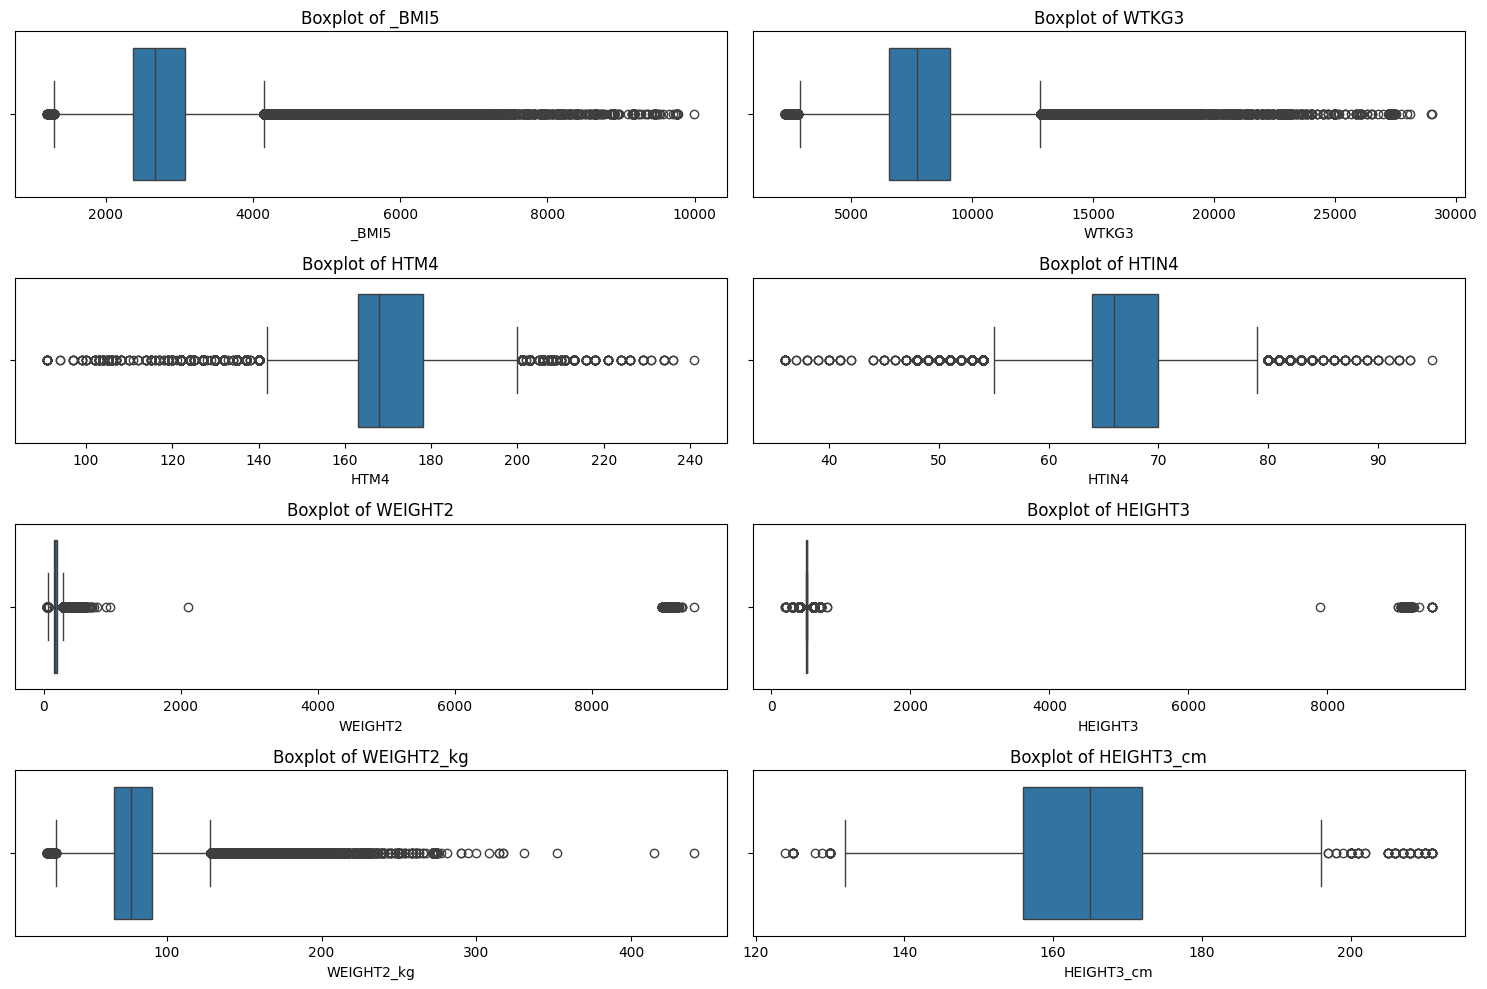

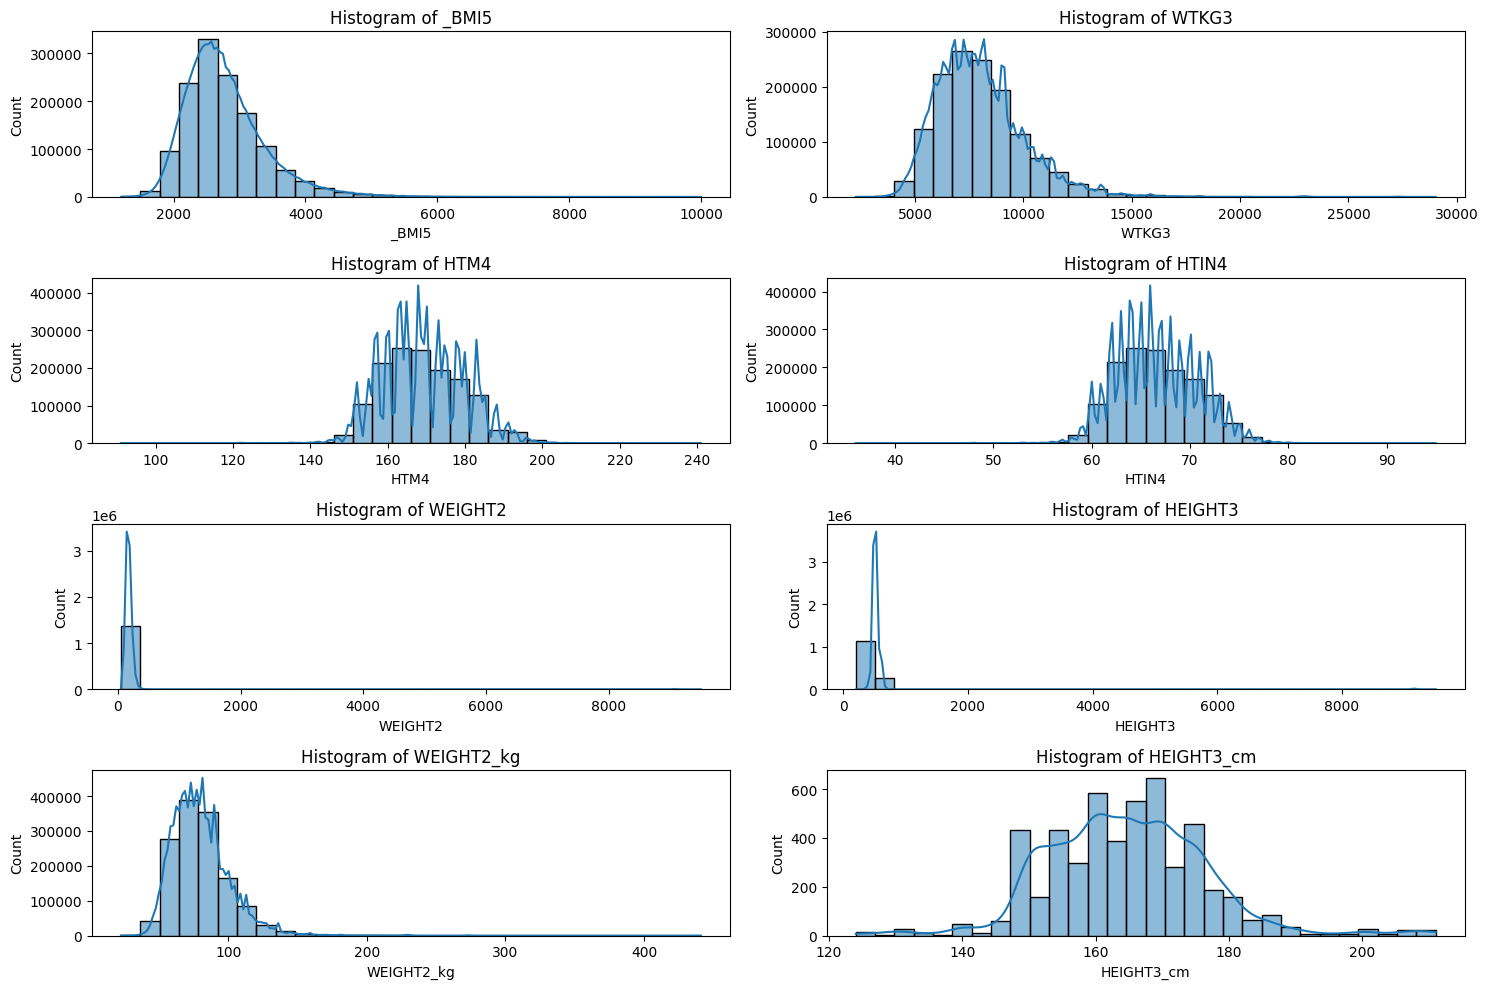

C:\Users\hasit\AppData\Local\Temp\ipykernel_24756\2133189095.py:119: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='_BMI5CAT_LABEL', data=subset_df, palette='pastel', order=bmi_labels.values())


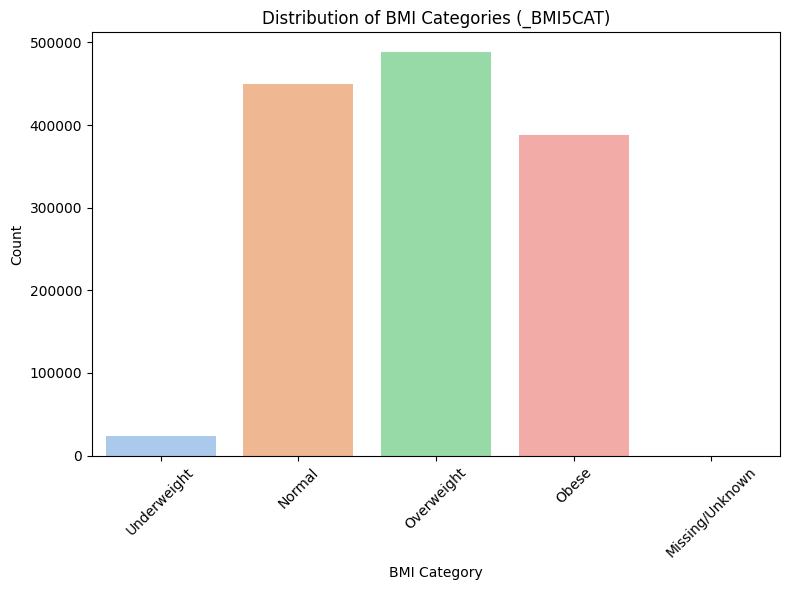

C:\Users\hasit\AppData\Local\Temp\ipykernel_24756\2133189095.py:130: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='_RFBMI5_LABEL', data=subset_df, palette='pastel', order=rfbmi_labels.values())


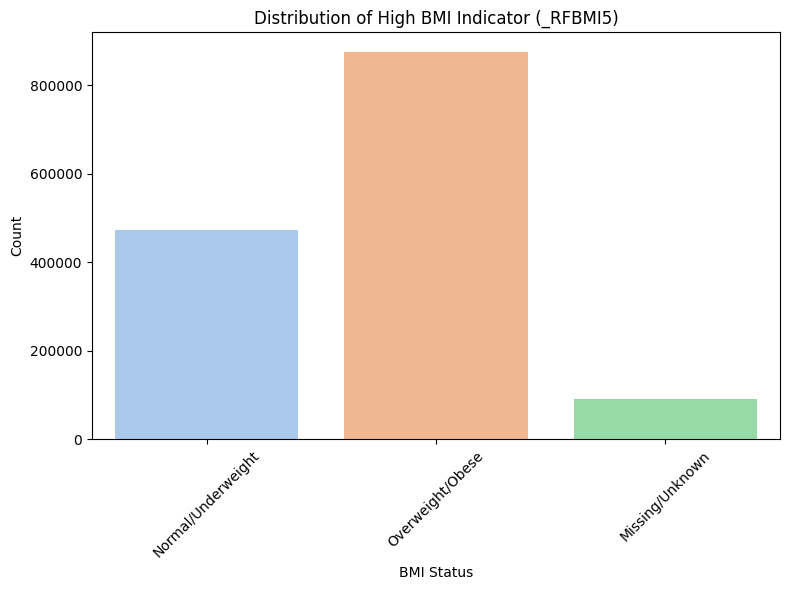

In [3]:
# Load the dataset
df = pd.read_csv('../data/raw/Behavioral_Risk_Factor_Surveillance_2011_2013_2015.csv', low_memory=False)
print(f"Dataset shape: {df.shape}")

# Columns to analyze
columns_to_analyze = ['_BMI5', '_BMI5CAT', '_RFBMI5', 'WEIGHT2', 'WTKG3', 'HEIGHT3', 'HTM4', 'HTIN4']

# Subset the dataset
subset_df = df[columns_to_analyze].copy()

# Define continuous and categorical columns
continuous_cols = ['_BMI5', 'WTKG3', 'HTM4', 'HTIN4', 'WEIGHT2', 'HEIGHT3']
categorical_cols = ['_BMI5CAT', '_RFBMI5']

# Step 1: Handle BRFSS special codes (7777, 9999 for "don't know"/"refused")
for col in continuous_cols:
    subset_df[col] = subset_df[col].replace([777, 7777, 999, 9999], np.nan)

# Step 2: Convert units for consistency
# Handle WEIGHT2 (pounds if <500, kg if 9000+)
subset_df['WEIGHT2_kg'] = subset_df['WEIGHT2'].apply(
    lambda x: x * 0.453592 if (x >= 50 and x <= 999) else 
              (x - 9000) if (x >= 9023 and x <= 9200) else np.nan
)
# Handle HEIGHT3 (inches if <800, cm if 9000+)
subset_df['HEIGHT3_cm'] = subset_df['HEIGHT3'].apply(
    lambda x: x * 2.54 if (x >= 48 and x <= 96) else 
              (x - 9000) if (x >= 9122 and x <= 9244) else np.nan
)

# Downcast numerical columns for memory efficiency
for col in continuous_cols + ['WEIGHT2_kg', 'HEIGHT3_cm']:
    subset_df[col] = pd.to_numeric(subset_df[col], errors='coerce', downcast='float')

# Convert categoricals to category dtype
for col in categorical_cols:
    subset_df[col] = subset_df[col].astype('category')

# Step 3: Consistency check (e.g., WTKG3 vs WEIGHT2_kg, HTM4 vs HEIGHT3_cm)
print("\nConsistency Check:")
# WTKG3 (kg*100) vs WEIGHT2_kg (kg)
subset_df['WTKG3_check'] = (subset_df['WTKG3'] / 100) / subset_df['WEIGHT2_kg']
print(f"WTKG3/WEIGHT2_kg ratio (should be ~1):")
print(subset_df['WTKG3_check'].describe())
# HTM4 (m*100) vs HEIGHT3_cm (cm)
subset_df['HTM4_check'] = subset_df['HTM4'] / subset_df['HEIGHT3_cm']
print(f"HTM4/HEIGHT3_cm ratio (should be ~1):")
print(subset_df['HTM4_check'].describe())

# Step 4: Descriptive Statistics
print("\nDescriptive Statistics for Continuous Columns:")
print(subset_df[continuous_cols + ['WEIGHT2_kg', 'HEIGHT3_cm']].describe())

# Step 5: Detect outliers (based on CDC/BRFSS and IQR)
print("\nOutlier Counts (based on CDC/BRFSS thresholds):")
outliers = {
    '_BMI5': ((subset_df['_BMI5'] / 100 < 15) | (subset_df['_BMI5'] / 100 > 50)).sum(),  # Adjusted for plausible range
    'WTKG3': ((subset_df['WTKG3'] / 100 < 22) | (subset_df['WTKG3'] / 100 > 200)).sum(),
    'HTM4': ((subset_df['HTM4'] / 100 < 0.91) | (subset_df['HTM4'] / 100 > 2.41)).sum(),
    'HTIN4': ((subset_df['HTIN4'] < 36) | (subset_df['HTIN4'] > 95)).sum(),
    'WEIGHT2_kg': ((subset_df['WEIGHT2_kg'] < 22) | (subset_df['WEIGHT2_kg'] > 200)).sum(),
    'HEIGHT3_cm': ((subset_df['HEIGHT3_cm'] < 91) | (subset_df['HEIGHT3_cm'] > 241)).sum()
}
for col, count in outliers.items():
    print(f"{col}: {count} outliers ({count/len(subset_df)*100:.2f}%)")

# Step 6: IQR-based outliers for comparison
def detect_outliers_iqr(data, column):
    valid_data = data[column].dropna()
    Q1 = valid_data.quantile(0.25)
    Q3 = valid_data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    mask = (data[column] < lower_bound) | (data[column] > upper_bound)
    return len(data.loc[mask, column]), lower_bound, upper_bound

print("\nIQR Outlier Counts:")
for col in continuous_cols + ['WEIGHT2_kg', 'HEIGHT3_cm']:
    if subset_df[col].notna().sum() > 0:
        iqr_count, lower, upper = detect_outliers_iqr(subset_df, col)
        print(f"{col}: {iqr_count} outliers (Lower: {lower:.2f}, Upper: {upper:.2f})")

# Step 7: Value Counts for Categorical Columns
print("\nValue Counts and Percentages for Categorical Columns:")
for col in categorical_cols:
    print(f"\n{col}:")
    counts = subset_df[col].value_counts(dropna=False, sort=False)
    percentages = (counts / len(subset_df) * 100).round(2)
    print(pd.DataFrame({'Count': counts, 'Percentage': percentages}))

# Step 8: Visualizations
# Boxplots for continuous columns
plt.figure(figsize=(15, 10))
for i, col in enumerate(continuous_cols + ['WEIGHT2_kg', 'HEIGHT3_cm'], 1):
    if subset_df[col].notna().sum() > 0:
        plt.subplot(4, 2, i)
        sns.boxplot(x=subset_df[col])
        plt.title(f'Boxplot of {col}')
        plt.xlabel(col)
plt.tight_layout()
plt.show()

# Histograms for continuous columns
plt.figure(figsize=(15, 10))
for i, col in enumerate(continuous_cols + ['WEIGHT2_kg', 'HEIGHT3_cm'], 1):
    if subset_df[col].notna().sum() > 0:
        plt.subplot(4, 2, i)
        sns.histplot(subset_df[col].dropna(), bins=30, kde=True)
        plt.title(f'Histogram of {col}')
        plt.xlabel(col)
plt.tight_layout()
plt.show()

# Bar plots for categorical columns
bmi_labels = {1: 'Underweight', 2: 'Normal', 3: 'Overweight', 4: 'Obese', 9: 'Missing/Unknown'}
subset_df['_BMI5CAT_LABEL'] = subset_df['_BMI5CAT'].map(bmi_labels)
plt.figure(figsize=(8, 6))
sns.countplot(x='_BMI5CAT_LABEL', data=subset_df, palette='pastel', order=bmi_labels.values())
plt.title('Distribution of BMI Categories (_BMI5CAT)')
plt.xlabel('BMI Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

rfbmi_labels = {1: 'Normal/Underweight', 2: 'Overweight/Obese', 9: 'Missing/Unknown'}
subset_df['_RFBMI5_LABEL'] = subset_df['_RFBMI5'].map(rfbmi_labels)
plt.figure(figsize=(8, 6))
sns.countplot(x='_RFBMI5_LABEL', data=subset_df, palette='pastel', order=rfbmi_labels.values())
plt.title('Distribution of High BMI Indicator (_RFBMI5)')
plt.xlabel('BMI Status')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Summary Statistics for Rescaled Columns:
                BMI      height_m     weight_kg
count  1.439696e+06  1.439696e+06  1.439696e+06
mean   2.770059e+01  1.692259e+00  7.992264e+01
std    5.761962e+00  1.039063e-01  1.977293e+01
min    1.500000e+01  9.100000e-01  2.268000e+01
25%    2.383000e+01  1.630000e+00  6.577000e+01
50%    2.663000e+01  1.680000e+00  7.711000e+01
75%    3.041000e+01  1.780000e+00  9.072000e+01
max    5.000000e+01  2.410000e+00  2.000000e+02


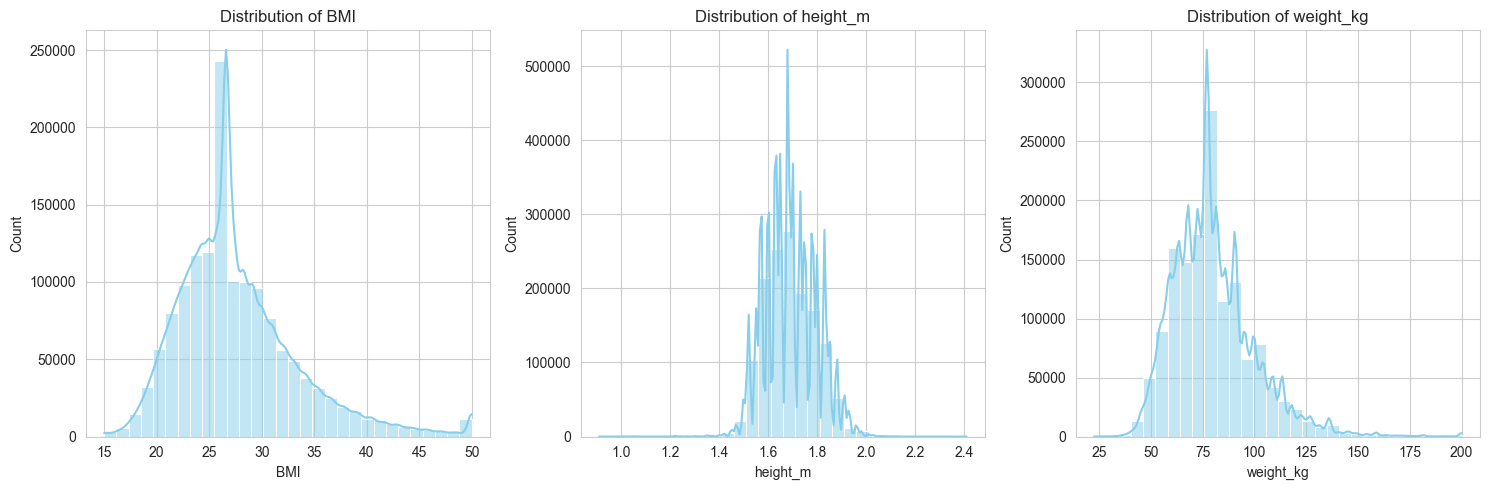

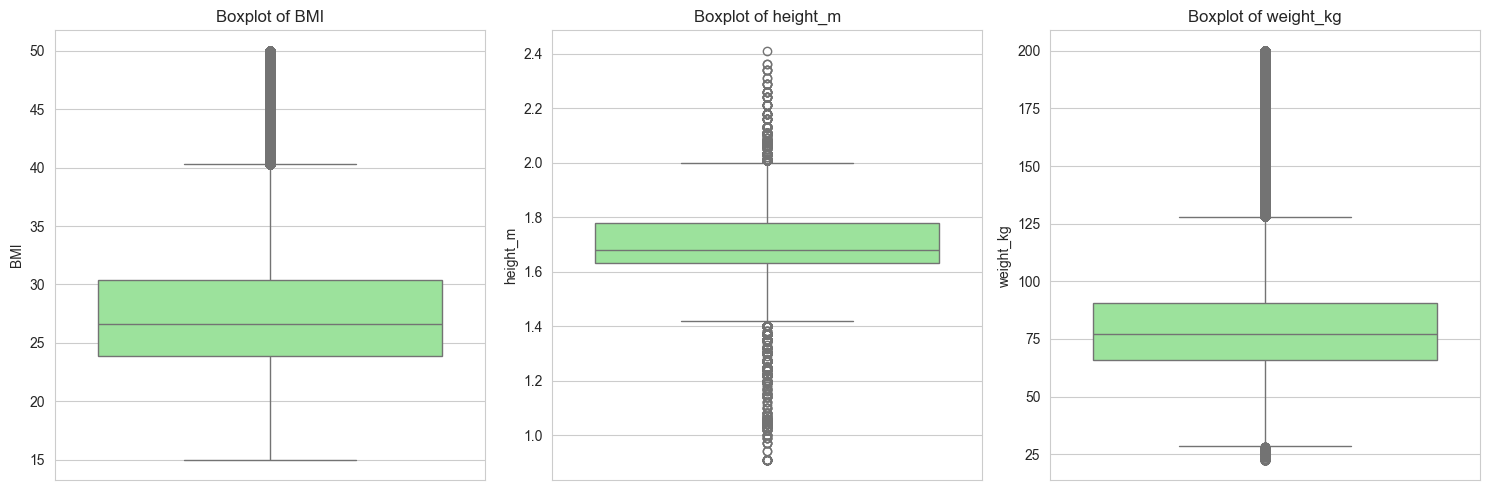

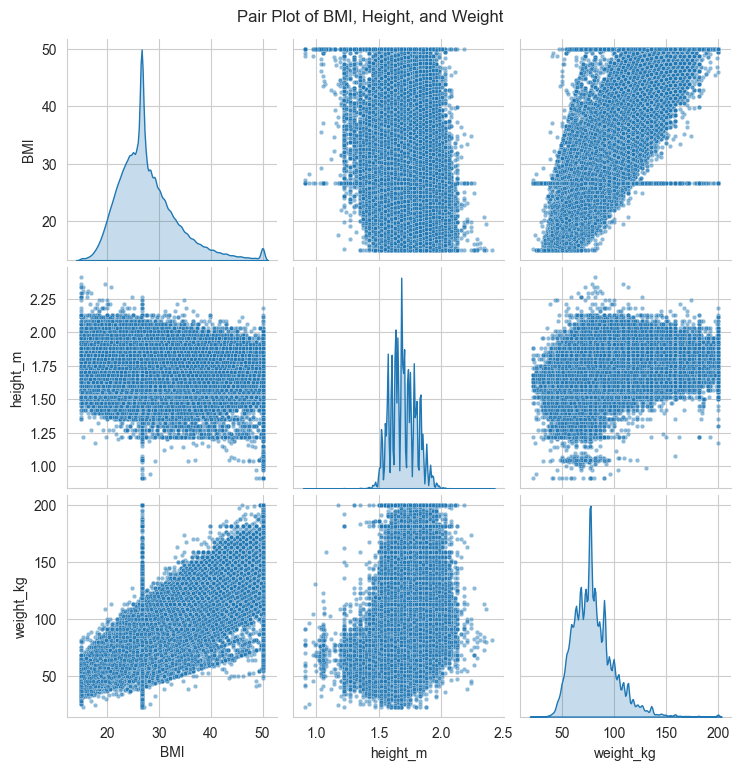

In [4]:
# Columns to rescale (based on BRFSS scaling: multiplied by 100)
bmi_col = '_BMI5'       # BMI * 100 (e.g., 3450 -> 34.5)
height_col = 'HTM4'     # Height in meters * 100 (e.g., 150 -> 1.5 m)
weight_col = 'WTKG3'    # Weight in kg * 100 (e.g., 8000 -> 80 kg)

# Handle any special codes or missing values (replace BRFSS codes like 9999 with NaN if not already done)
for col in [bmi_col, height_col, weight_col]:
    df[col] = df[col].replace([777, 7777, 999, 9999], np.nan)

# Create new rescaled columns
df['BMI'] = df[bmi_col] / 100.0  # Rescale to standard BMI (e.g., 34.5)
df['height_m'] = df[height_col] / 100.0  # Rescale to meters (e.g., 1.5)
df['weight_kg'] = df[weight_col] / 100.0  # Rescale to kg (e.g., 80.0)

# Handle outliers by capping based on plausible ranges (CDC-informed)
df['BMI'] = df['BMI'].clip(lower=15, upper=50)
df['height_m'] = df['height_m'].clip(lower=0.91, upper=2.41)
df['weight_kg'] = df['weight_kg'].clip(lower=22, upper=200)

# Impute missing values with median
for col in ['BMI', 'height_m', 'weight_kg']:
    df[col] = df[col].fillna(df[col].median())

# Verify changes with summary statistics
print("\nSummary Statistics for Rescaled Columns:")
print(df[['BMI', 'height_m', 'weight_kg']].describe())

# Visualizations
# Set up plot style
sns.set_style("whitegrid")

# 1. Histograms with KDE
plt.figure(figsize=(15, 5))
for i, col in enumerate(['BMI', 'height_m', 'weight_kg'], 1):
    plt.subplot(1, 3, i)
    sns.histplot(df[col], bins=30, kde=True, color='skyblue')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
plt.tight_layout()
plt.show()

# 2. Boxplots
plt.figure(figsize=(15, 5))
for i, col in enumerate(['BMI', 'height_m', 'weight_kg'], 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=df[col], color='lightgreen')
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

# 3. Pair Plot (relationships between features)
sns.pairplot(df[['BMI', 'height_m', 'weight_kg']], diag_kind='kde', plot_kws={'alpha': 0.5, 's': 10})
plt.suptitle('Pair Plot of BMI, Height, and Weight', y=1.02)
plt.show()



BMI median used for imputation: 26.63
Shape after dropping ['_BMI5', '_BMI5CAT', '_RFBMI5', 'WEIGHT2', 'WTKG3', 'HEIGHT3', 'HTM4', 'HTIN4', 'BMICal']: (1439696, 211)

Summary Statistics for Final BMI:
                BMI
count  1.439696e+06
mean   2.770059e+01
std    5.761962e+00
min    1.500000e+01
25%    2.383000e+01
50%    2.663000e+01
75%    3.041000e+01
max    5.000000e+01


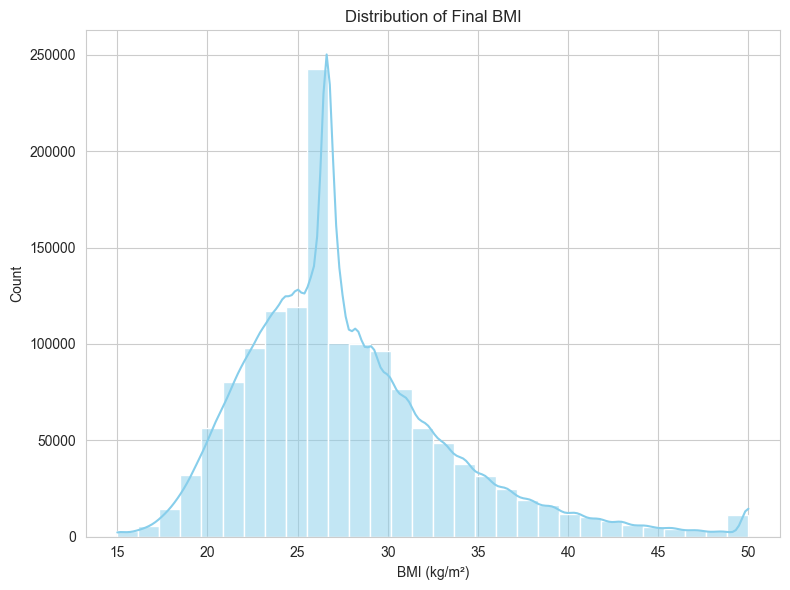

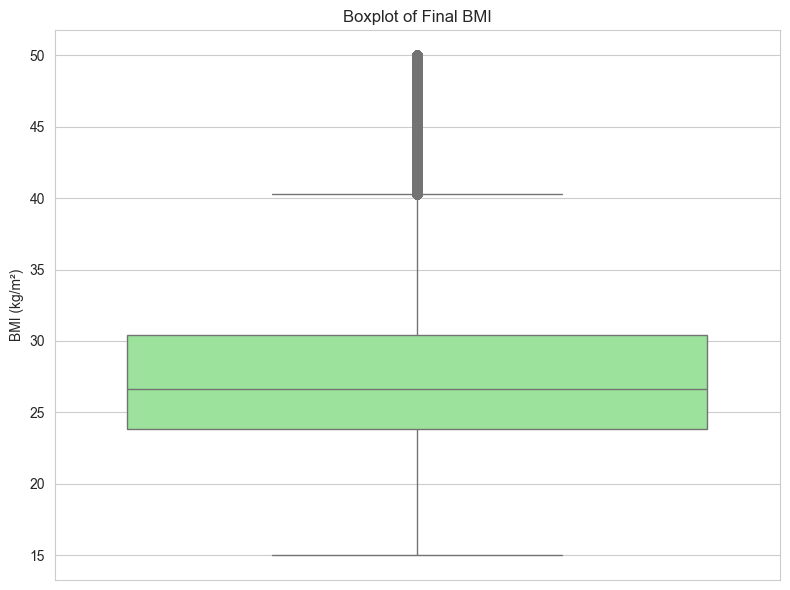


Updated dataset saved to: ../data/processed/BRFSS_1_BMI.csv


In [5]:
# Columns of interest
bmi_col = 'BMI'
height_col = 'height_m'
weight_col = 'weight_kg'
drop_cols = ['_BMI5', '_BMI5CAT', '_RFBMI5', 'WEIGHT2', 'WTKG3', 'HEIGHT3', 'HTM4', 'HTIN4']

# Step 1: Create BMICal from weight_kg and height_m
df['BMICal'] = df[weight_col] / (df[height_col] ** 2)

# Cap BMICal to plausible range (15-50, same as BMI)
df['BMICal'] = df['BMICal'].clip(lower=15, upper=50)

# Step 2: Fill missing BMI with BMICal where available, then median
df[bmi_col] = df.apply(
    lambda row: row['BMICal'] if pd.isna(row[bmi_col]) and not pd.isna(row['BMICal']) else row[bmi_col],
    axis=1
)
# Fill remaining missing BMI with median
bmi_median = df[bmi_col].median()
df[bmi_col] = df[bmi_col].fillna(bmi_median)
print(f"\nBMI median used for imputation: {bmi_median}")

# Step 3: Drop original and temporary columns
df = df.drop(columns=drop_cols + ['BMICal'])
print(f"Shape after dropping {drop_cols + ['BMICal']}: {df.shape}")

# Step 4: Summary statistics for final BMI
print("\nSummary Statistics for Final BMI:")
print(df[[bmi_col]].describe())

# Step 5: Visualizations for BMI
sns.set_style("whitegrid")

# Histogram with KDE
plt.figure(figsize=(8, 6))
sns.histplot(df[bmi_col], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Final BMI')
plt.xlabel('BMI (kg/m²)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(y=df[bmi_col], color='lightgreen')
plt.title('Boxplot of Final BMI')
plt.ylabel('BMI (kg/m²)')
plt.tight_layout()
plt.show()

# Step 6: Save the updated dataset
updated_path = '../data/processed/BRFSS_1_BMI.csv'
df.to_csv(updated_path, index=False)
print(f"\nUpdated dataset saved to: {updated_path}")

## LifeStyle Features

Dataset shape: (1439696, 211)

Columns to analyze: ['FRUIT1', 'FRUITJU1', 'FVBEANS', 'FVGREEN', 'FVORANG', 'VEGETAB1', '_FRUTSUM', '_VEGESUM', 'FTJUDA1_', 'GRENDAY_', 'VEGEDA1_', 'FRUTDA1_', 'BEANDAY_', 'ORNGDAY_', '_FRUITEX', '_VEGETEX', '_MISFRTN', '_VEG23', '_FRT16', 'SMOKE100', 'SMOKDAY2', '_SMOKER3', '_RFSMOK3', 'ALCDAY5', 'AVEDRNK2', 'DRNK3GE5', 'MAXDRNKS', '_RFBING5', 'DROCDY3_', 'DRNKANY5']

Summary Statistics for Numerical Columns:
             FRUIT1       FRUITJU1       FVBEANS       FVGREEN       FVORANG  \
count  1.292328e+06  836026.000000  1.108130e+06  1.234762e+06  1.144069e+06   
mean   1.058614e+00       0.638173  3.332854e-01  5.972472e-01  3.427620e-01   
std    1.091038e+00       0.833411  4.631998e-01  6.460640e-01  4.320529e-01   
min    0.000000e+00       0.000000  0.000000e+00  0.000000e+00  0.000000e+00   
25%    4.285714e-01       0.142857  1.333333e-01  2.333333e-01  1.333333e-01   
50%    1.000000e+00       0.428571  2.000000e-01  4.285714e-01  2.333333e-0

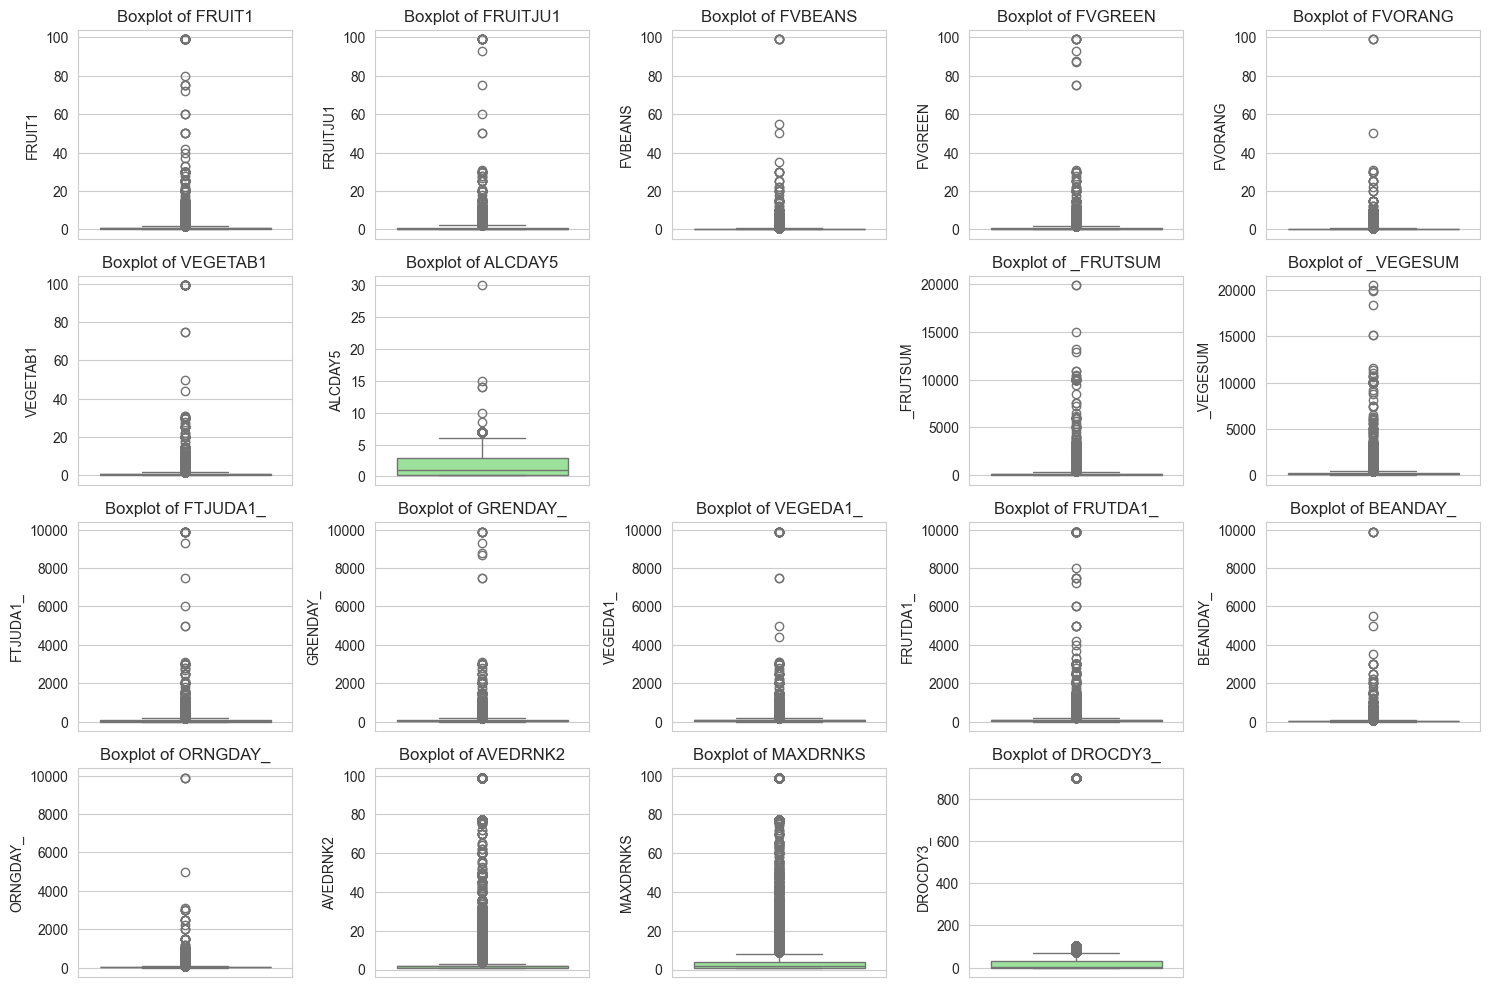

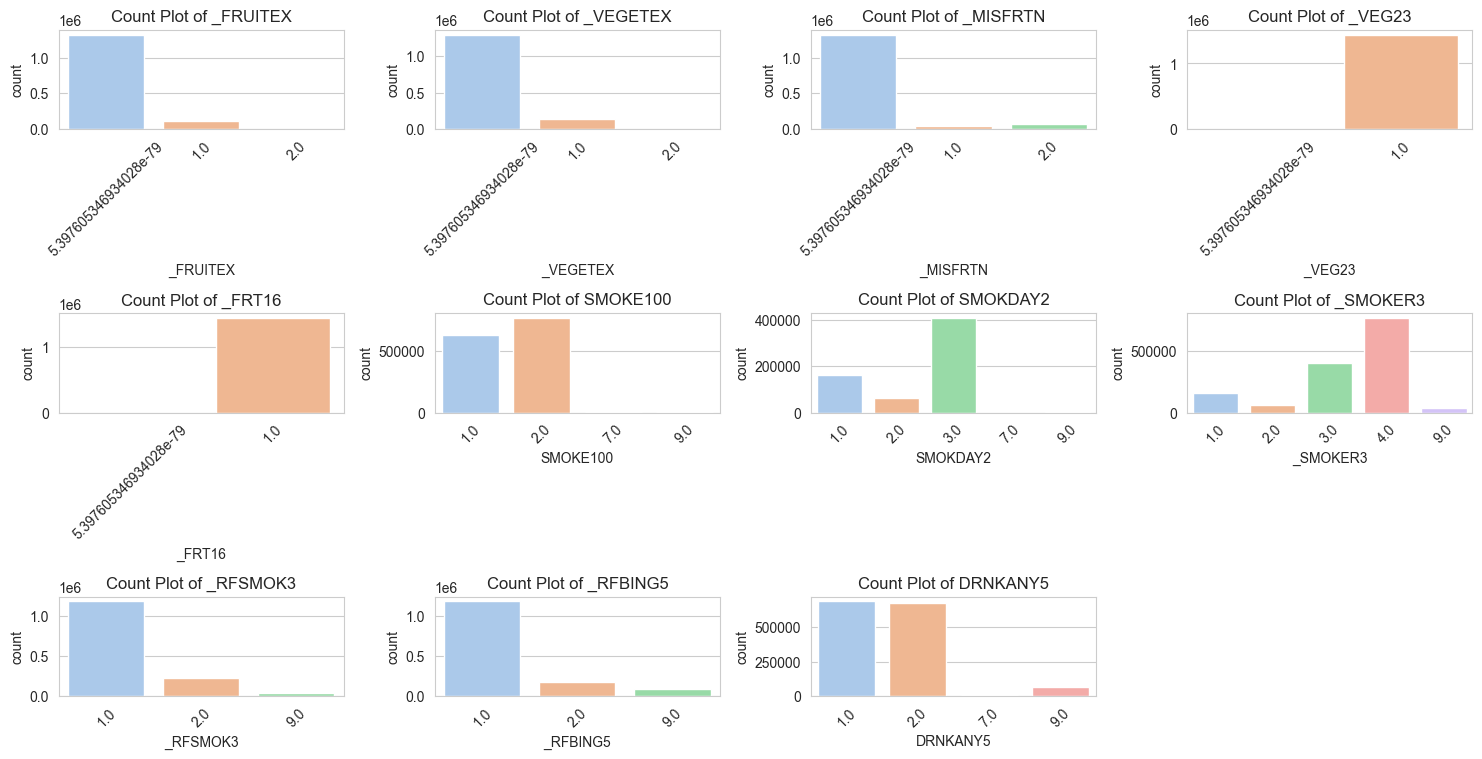

In [6]:
# Load the dataset
df = pd.read_csv('../data/processed/BRFSS_1_BMI.csv', low_memory=False)
print(f"Dataset shape: {df.shape}")

# Define columns (remove duplicates)
diet_cols = ['FRUIT1', 'FRUITJU1', 'FVBEANS', 'FVGREEN', 'FVORANG', 'VEGETAB1',
             '_FRUTSUM', '_VEGESUM', 'FTJUDA1_', 'GRENDAY_', 'VEGEDA1_',
             'FRUTDA1_', 'BEANDAY_', 'ORNGDAY_', '_FRUITEX', '_VEGETEX',
             '_MISFRTN', '_VEG23', '_FRT16']
smoking_cols = ['SMOKE100', 'SMOKDAY2', '_SMOKER3', '_RFSMOK3']
alcohol_cols = ['ALCDAY5', 'AVEDRNK2', 'DRNK3GE5', 'MAXDRNKS', '_RFBING5', 'DROCDY3_', 'DRNKANY5']

# Combine all columns
all_cols = diet_cols + smoking_cols + alcohol_cols
print(f"\nColumns to analyze: {all_cols}")

# Subset the dataset
subset_df = df[all_cols].copy()

# Define numerical and categorical columns
numerical_cols = ['FRUIT1', 'FRUITJU1', 'FVBEANS', 'FVGREEN', 'FVORANG', 'VEGETAB1',
                  '_FRUTSUM', '_VEGESUM', 'FTJUDA1_', 'GRENDAY_', 'VEGEDA1_',
                  'FRUTDA1_', 'BEANDAY_', 'ORNGDAY_', 'ALCDAY5', 'AVEDRNK2',
                  'DRNK3GE5', 'MAXDRNKS', 'DROCDY3_']
categorical_cols = ['_FRUITEX', '_VEGETEX', '_MISFRTN', '_VEG23', '_FRT16',
                   'SMOKE100', 'SMOKDAY2', '_SMOKER3',
                   '_RFSMOK3', '_RFBING5', 'DRNKANY5']

# Step 1: Preprocess numerical columns
# Convert raw frequency columns to daily rates
freq_cols = ['FRUIT1', 'FRUITJU1', 'FVBEANS', 'FVGREEN', 'FVORANG', 'VEGETAB1', 'ALCDAY5', 'DRNK3GE5']
for col in freq_cols:
    subset_df[col] = subset_df[col].replace([777, 7777, 999, 9999, 888], np.nan)
    # Convert to daily: 100-199 (daily), 200-299 (weekly/7), 300-399 (monthly/30)
    subset_df[f'{col}'] = subset_df[col].apply(
        lambda x: x - 100 if 100 <= x <= 199 else (x - 200) / 7 if 200 <= x <= 299 else (x - 300) / 30 if 300 <= x <= 399 else np.nan
    )
numerical_cols = [f'{col}' for col in freq_cols] + [col for col in numerical_cols if col not in freq_cols]

# Handle special codes for other numerical columns
for col in numerical_cols:
    if col not in [f'{c}' for c in freq_cols]:
        subset_df[col] = subset_df[col].replace([777, 7777, 999, 9999, 888], np.nan)

# Convert to float for numerical columns
for col in numerical_cols:
    subset_df[col] = pd.to_numeric(subset_df[col], errors='coerce', downcast='float')

# Convert categorical columns to category dtype
for col in categorical_cols:
    subset_df[col] = subset_df[col].astype('category')

# Step 2: Numerical Analysis
# Summary statistics for numerical columns
print("\nSummary Statistics for Numerical Columns:")
print(subset_df[numerical_cols].describe())

# Outlier detection using IQR
def detect_outliers_iqr(data, column):
    valid_data = data[column].dropna()
    Q1 = valid_data.quantile(0.25)
    Q3 = valid_data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    mask = (data[column] < lower_bound) | (data[column] > upper_bound)
    return len(data.loc[mask, column]), lower_bound, upper_bound

print("\nIQR Outlier Counts for Numerical Columns:")
for col in numerical_cols:
    if subset_df[col].notna().sum() > 0:
        iqr_count, lower, upper = detect_outliers_iqr(subset_df, col)
        print(f"{col}: {iqr_count} outliers (Lower: {lower:.2f}, Upper: {upper:.2f})")

# Value counts for categorical columns
print("\nValue Counts for Categorical Columns:")
for col in categorical_cols:
    print(f"\n{col}:")
    counts = subset_df[col].value_counts(dropna=False)
    percentages = (counts / len(subset_df) * 100).round(2)
    print(pd.DataFrame({'Count': counts, 'Percentage': percentages}))

# Step 3: Visualizations
sns.set_style("whitegrid")

# Boxplots for numerical columns
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols, 1):
    if subset_df[col].notna().sum() > 0:
        plt.subplot(4, 5, i)
        sns.boxplot(y=subset_df[col], color='lightgreen')
        plt.title(f'Boxplot of {col}')
        plt.ylabel(col)
plt.tight_layout()
plt.show()

# Count plots for categorical columns — FIXED
plt.figure(figsize=(15, 10))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(4, 4, i)
    # Fix: add hue=col and legend=False
    sns.countplot(
        x=subset_df[col],
        hue=subset_df[col],      
        palette='pastel',
        legend=False           
    )
    plt.title(f'Count Plot of {col}')
    plt.xlabel(col)
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



Original dataset shape: (1439696, 211)
Note: '_RFSEAT3', '_RFSEAT2' not found in dataset. Excluded from analysis.

Summary Statistics for Engineered Features:
         diet_score  smoking_status  alcohol_level
count  1.301792e+06    1.439696e+06   1.439688e+06
mean   3.318348e+00    7.050197e-01   7.801188e+00
std    2.060242e+00    9.820116e-01   8.710711e+00
min    1.079521e-80    0.000000e+00   5.397605e-79
25%    1.920000e+00    0.000000e+00   5.397605e-79
50%    2.960000e+00    0.000000e+00   3.000000e+00
75%    4.270000e+00    1.000000e+00   2.000000e+01
max    2.000000e+01    3.000000e+00   2.000000e+01

IQR Outlier Counts for Engineered Features:
diet_score: 46672 outliers (Lower: -1.60, Upper: 7.79)
smoking_status: 160767 outliers (Lower: -1.50, Upper: 2.50)
alcohol_level: 0 outliers (Lower: -30.00, Upper: 50.00)

Value Counts for smoking_status:
                 Count  Percentage
smoking_status                    
0.0             808393       56.15
1.0             408359     

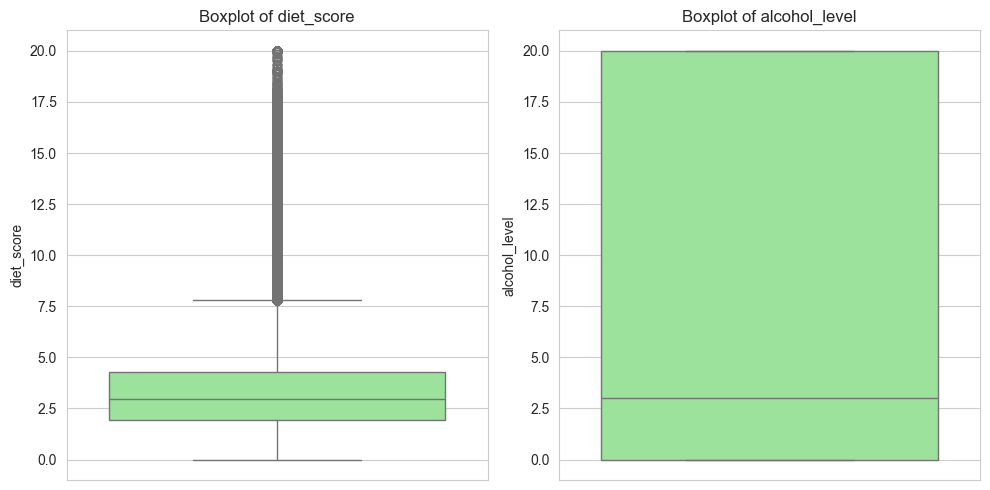

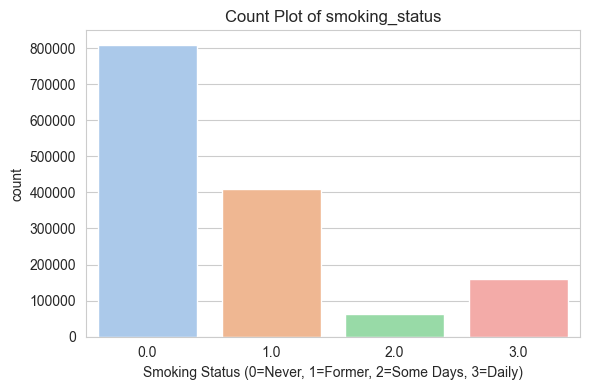


Updated dataset saved to: ../data/processed/BRFSS_2_Lifestyle.csv


<Figure size 800x600 with 0 Axes>

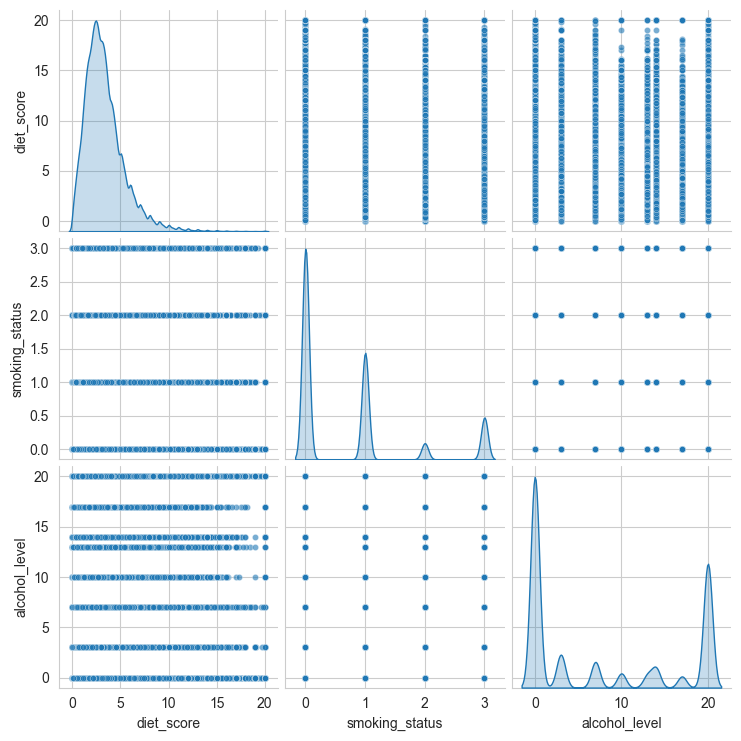

In [7]:
# Set pandas option to avoid downcasting warning
pd.set_option('future.no_silent_downcasting', True)

# Load the dataset
df = pd.read_csv('../data/processed/BRFSS_1_BMI.csv', low_memory=False)
print(f"Original dataset shape: {df.shape}")

# Define columns
diet_cols = ['FRUIT1', 'FRUITJU1', 'FVBEANS', 'FVGREEN', 'FVORANG', 'VEGETAB1',
             '_FRUTSUM', '_VEGESUM', 'FTJUDA1_', 'GRENDAY_', 'VEGEDA1_',
             'FRUTDA1_', 'BEANDAY_', 'ORNGDAY_', '_FRUITEX', '_VEGETEX',
             '_MISFRTN', '_VEG23', '_FRT16']
smoking_cols = ['SMOKE100', 'SMOKDAY2', '_SMOKER3', '_RFSMOK3']
alcohol_cols = ['ALCDAY5', 'AVEDRNK2', 'DRNK3GE5', 'MAXDRNKS', '_RFBING5', 'DROCDY3_', 'DRNKANY5']

# Remove duplicates and flag irrelevant columns
diet_cols = list(dict.fromkeys(diet_cols))

# Combine all columns to drop
drop_cols = diet_cols + smoking_cols + alcohol_cols

# Define columns needed for engineering
eng_cols = ['_FRUTSUM', '_VEGESUM', '_SMOKER3', 'DROCDY3_']

# Subset the dataset
subset_df = df[eng_cols].copy()

# Step 1: Preprocess numerical columns
# Cap outliers at plausible ranges

# Convert BRFSS scaled variables to proper units
subset_df['_FRUTSUM'] = subset_df['_FRUTSUM'] / 100.0  # Now in "times/day"
subset_df['_VEGESUM'] = subset_df['_VEGESUM'] / 100.0

# Handle special codes
for col in ['_FRUTSUM', '_VEGESUM', 'DROCDY3_']:
    subset_df[col] = subset_df[col].replace([777, 7777, 999, 9999, 888], np.nan)

# Cap at plausible maxima (NO division by 100 for DROCDY3_)
subset_df['_FRUTSUM'] = subset_df['_FRUTSUM'].clip(upper=10)  # Max 10 fruit/day
subset_df['_VEGESUM'] = subset_df['_VEGESUM'].clip(upper=10)  # Max 10 veg/day
subset_df['DROCDY3_'] = subset_df['DROCDY3_'].clip(upper=20)  # Max 20 drinks/day (CDC extreme)

# Step 2: Preprocess categorical column
subset_df['_SMOKER3'] = subset_df['_SMOKER3'].astype('category')
mode = subset_df['_SMOKER3'].mode()[0] if not subset_df['_SMOKER3'].mode().empty else np.nan
subset_df['_SMOKER3'] = subset_df['_SMOKER3'].astype(object).fillna(mode).astype('category')

# Step 3: Engineer 3 features
# 1. Diet Score: Sum of _FRUTSUM and _VEGESUM (times/day)
subset_df['diet_score'] = (subset_df['_FRUTSUM'] + subset_df['_VEGESUM'])

# 2. Smoking Status: Map _SMOKER3 to ordinal (0=never, 1=former, 2=some days, 3=daily)
smoking_map = {4.0: 0, 3.0: 1, 2.0: 2, 1.0: 3, 9.0: 0}  # Imputed 9.0 as never
subset_df['smoking_status'] = subset_df['_SMOKER3'].map(smoking_map).astype(float)

# 3. Alcohol Level: Use DROCDY3_ (drinks/day)
subset_df['alcohol_level'] = subset_df['DROCDY3_']

# Step 4: Numerical Analysis
new_features = ['diet_score', 'smoking_status', 'alcohol_level']
print("\nSummary Statistics for Engineered Features:")
print(subset_df[new_features].describe())

# IQR Outlier Counts
def detect_outliers_iqr(data, column):
    valid_data = data[column].dropna()
    Q1 = valid_data.quantile(0.25)
    Q3 = valid_data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    mask = (data[column] < lower_bound) | (data[column] > upper_bound)
    return len(data.loc[mask, column]), lower_bound, upper_bound

print("\nIQR Outlier Counts for Engineered Features:")
for col in new_features:
    iqr_count, lower, upper = detect_outliers_iqr(subset_df, col)
    print(f"{col}: {iqr_count} outliers (Lower: {lower:.2f}, Upper: {upper:.2f})")

# Value Counts for smoking_status
print("\nValue Counts for smoking_status:")
counts = subset_df['smoking_status'].value_counts(dropna=False)
percentages = (counts / len(subset_df) * 100).round(2)
print(pd.DataFrame({'Count': counts, 'Percentage': percentages}))

# Step 5: Visualizations
sns.set_style("whitegrid")

# Boxplots for diet_score and alcohol_level
plt.figure(figsize=(10, 5))
for i, col in enumerate(['diet_score', 'alcohol_level'], 1):
    plt.subplot(1, 2, i)
    sns.boxplot(y=subset_df[col], color='lightgreen')
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

# Count plot for smoking_status
plt.figure(figsize=(6, 4))
sns.countplot(x=subset_df['smoking_status'], hue=subset_df['smoking_status'], palette='pastel', legend=False)
plt.title('Count Plot of smoking_status')
plt.xlabel('Smoking Status (0=Never, 1=Former, 2=Some Days, 3=Daily)')
plt.tight_layout()
plt.show()



plt.figure(figsize=(8, 6))

# Pairplot to visualize scatterplot matrix
sns.pairplot(
    subset_df[new_features],
    diag_kind='kde',             # KDE on the diagonal
    plot_kws={'alpha': 0.6, 's': 20}  # transparency & point size
)

# Step 6: Update the dataset
df = df.drop(columns=drop_cols + numerical_cols + categorical_cols)
df[new_features] = subset_df[new_features]
updated_path = '../data/processed/BRFSS_2_Lifestyle.csv'
df.to_csv(updated_path, index=False)
print(f"\nUpdated dataset saved to: {updated_path}")

In [8]:
# Load CSV file 
df = pd.read_csv('../data/processed/BRFSS_2_Lifestyle.csv')

# Show dataset dimensions
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

# Show feature (column) names
print("\nFeature names (columns):")
print(df.columns.tolist())

# Show first 5 rows of the dataset
print("\nFirst 5 rows of the dataset:")
print(df.head())

# Show dataset info 
print("\nDataset Info:")
print(df.info())


Number of rows: 1439696
Number of columns: 184

Feature names (columns):
['_WT2RAKE', 'FMONTH', 'USEEQUIP', 'CADULT', 'LASTSIG3', 'BLDSUGAR', 'EXERANY2', 'HOWLONG', 'PDIABTST', 'QSTVER', 'HADSIGM3', 'BPHIGH4', 'QLACTLM2', 'DIABETE3', 'PHYSHLTH', 'RCSRLTN2', 'NUMMEN', 'IMFVPLAC', 'FEETCHK2', 'VETERAN3', 'PREDIAB1', 'SEQNO', 'MISTMNT', 'QLSTRES2', 'CASTHDX2', 'DISPCODE', 'CASTHNO2', 'CHCOCNCR', 'SCNTPAID', 'CTELNUM1', 'SEATBELT', 'INSULIN', 'LSTBLDS3', '_STATE', 'CELLFON2', 'PVTRESD2', 'MSCODE', '_PSU', '_CHLDCNT', 'HADHYST2', 'EMTSUPRT', 'PADUR2_', 'BPMEDS', '_CLLCPWT', 'IMONTH', '_LLCPWT', 'BLDSTOOL', 'CHILDREN', '_RFSEAT2', '_INCOMG', 'HIVTSTD3', 'DIABEYE', 'USENOW3', '_TOTINDA', 'ASTHNOW', 'FLSHTMY2', 'ASERVIST', 'QLMENTL2', 'LMTJOIN3', 'SEX', 'DIABEDU', 'PREGNANT', '_PNEUMO2', 'TOLDHI2', 'HIVTST6', 'EXERHMM2', 'JOINPAIN', 'PNEUVAC3', '_RFHYPE5', '_RAWRAKE', '_PASTRNG', 'FC60_', 'IYEAR', '_MISVEGN', 'CHCKIDNY', 'MEDCOST', 'CVDASPRN', 'GENHLTH', 'ASNOSLEP', 'MARITAL', 'ASTHMED3', '_LT

## Health Conditions

Dataset shape: (1439696, 184)

Summary Statistics for Numerical Columns:
            MENTHLTH       PHYSHLTH       POORHLTH       EXERHMM1  \
count  418697.000000  488107.000000  298443.000000  954548.000000   
mean       11.114500      12.102826      12.454251      92.915232   
std        10.658384      11.422077      11.144644     113.318230   
min         1.000000       1.000000       1.000000       1.000000   
25%         2.000000       2.000000       2.000000      30.000000   
50%         5.000000       5.000000      10.000000      45.000000   
75%        20.000000      25.000000      21.000000     100.000000   
max        30.000000      30.000000      30.000000     959.000000   

           EXERHMM2       EXEROFT1       EXEROFT2       STRENGTH      STRFREQ_  
count  6.116400e+05  966449.000000  622236.000000  495358.000000  1.327049e+06  
mean   1.082666e+02     134.553082     138.158334     137.103636  1.151936e+03  
std    1.321848e+02      49.873570      50.548626      49.8640

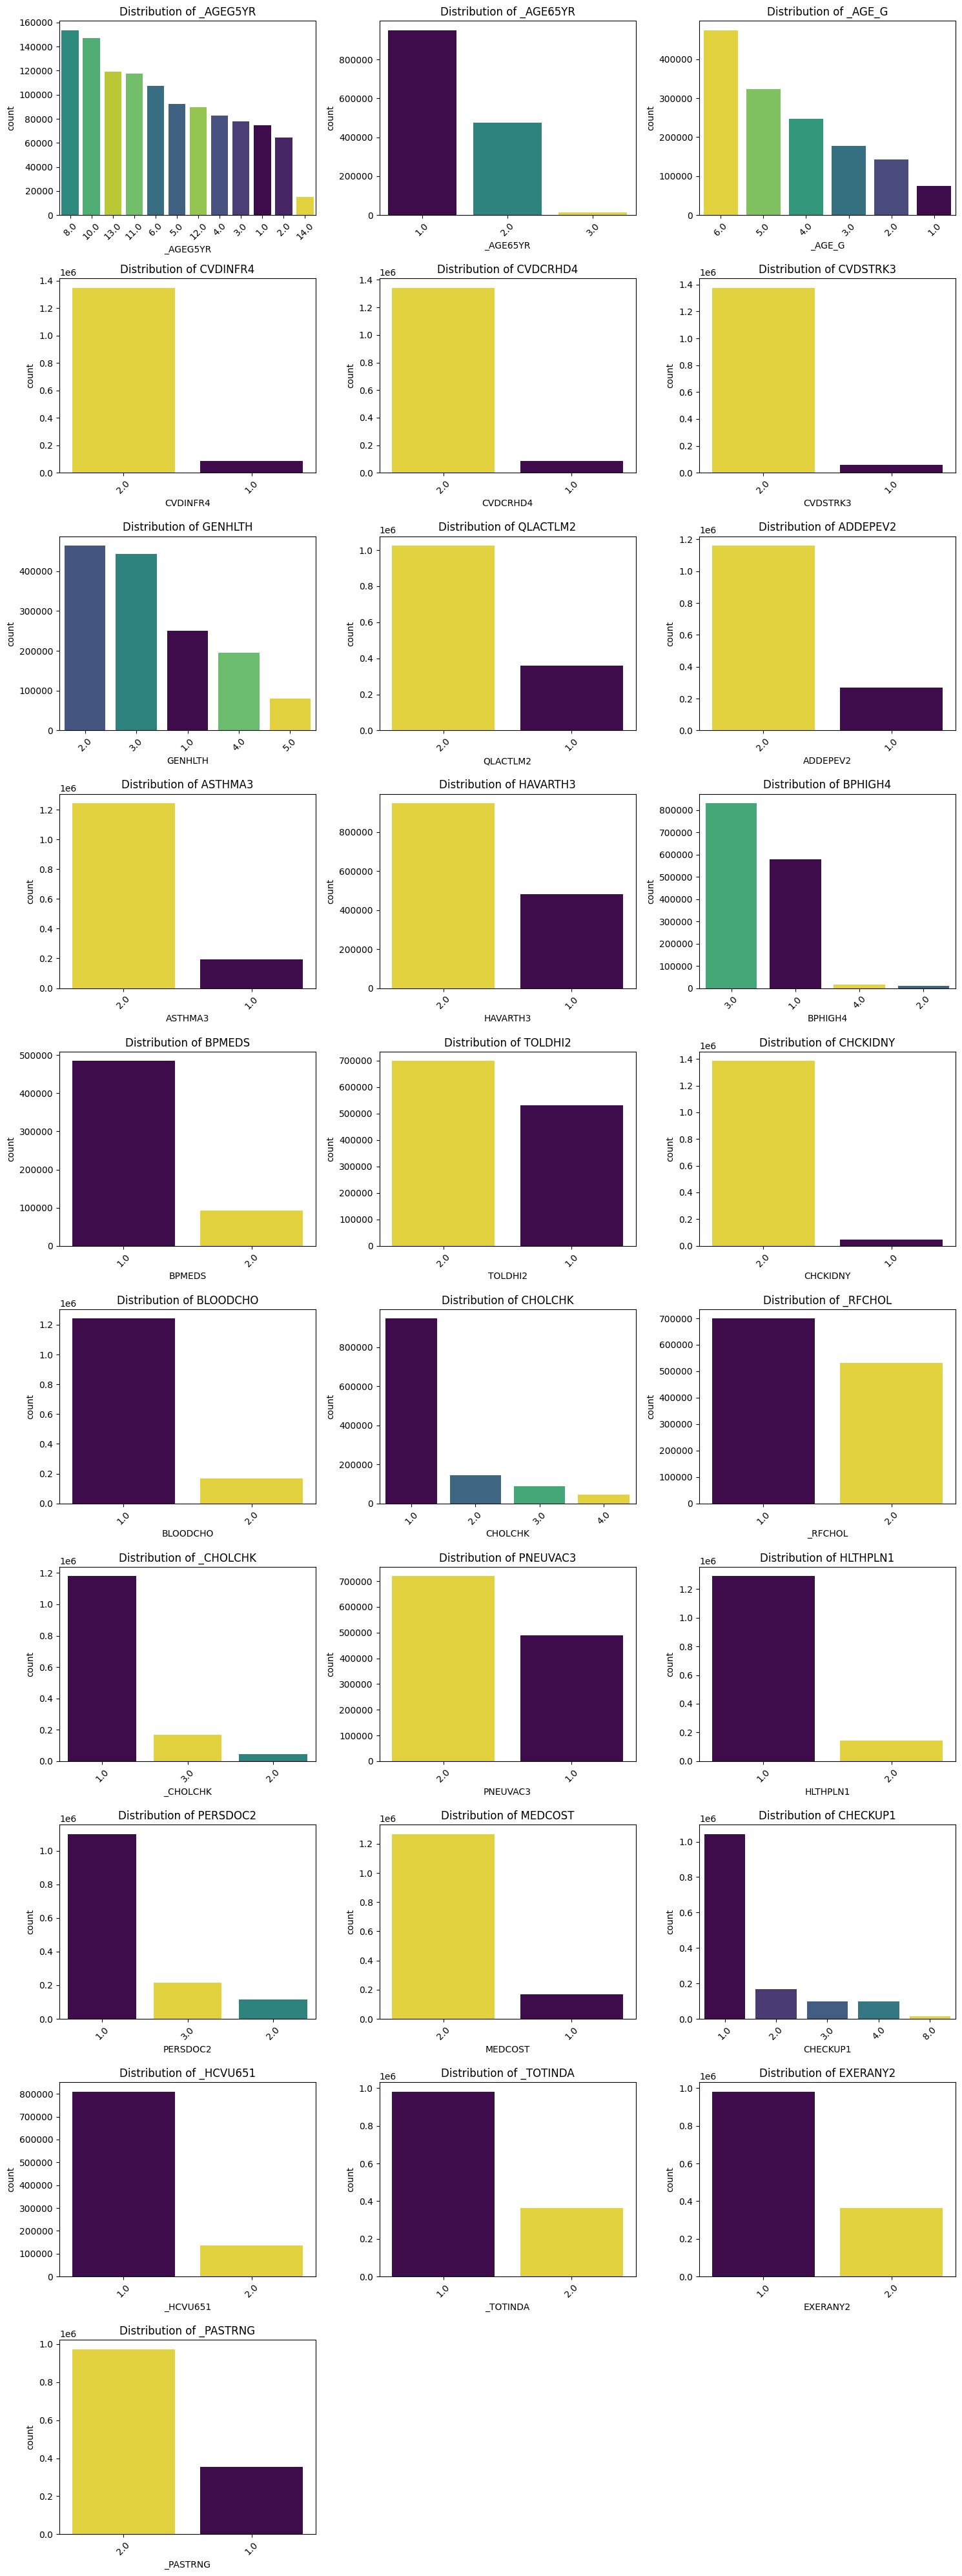

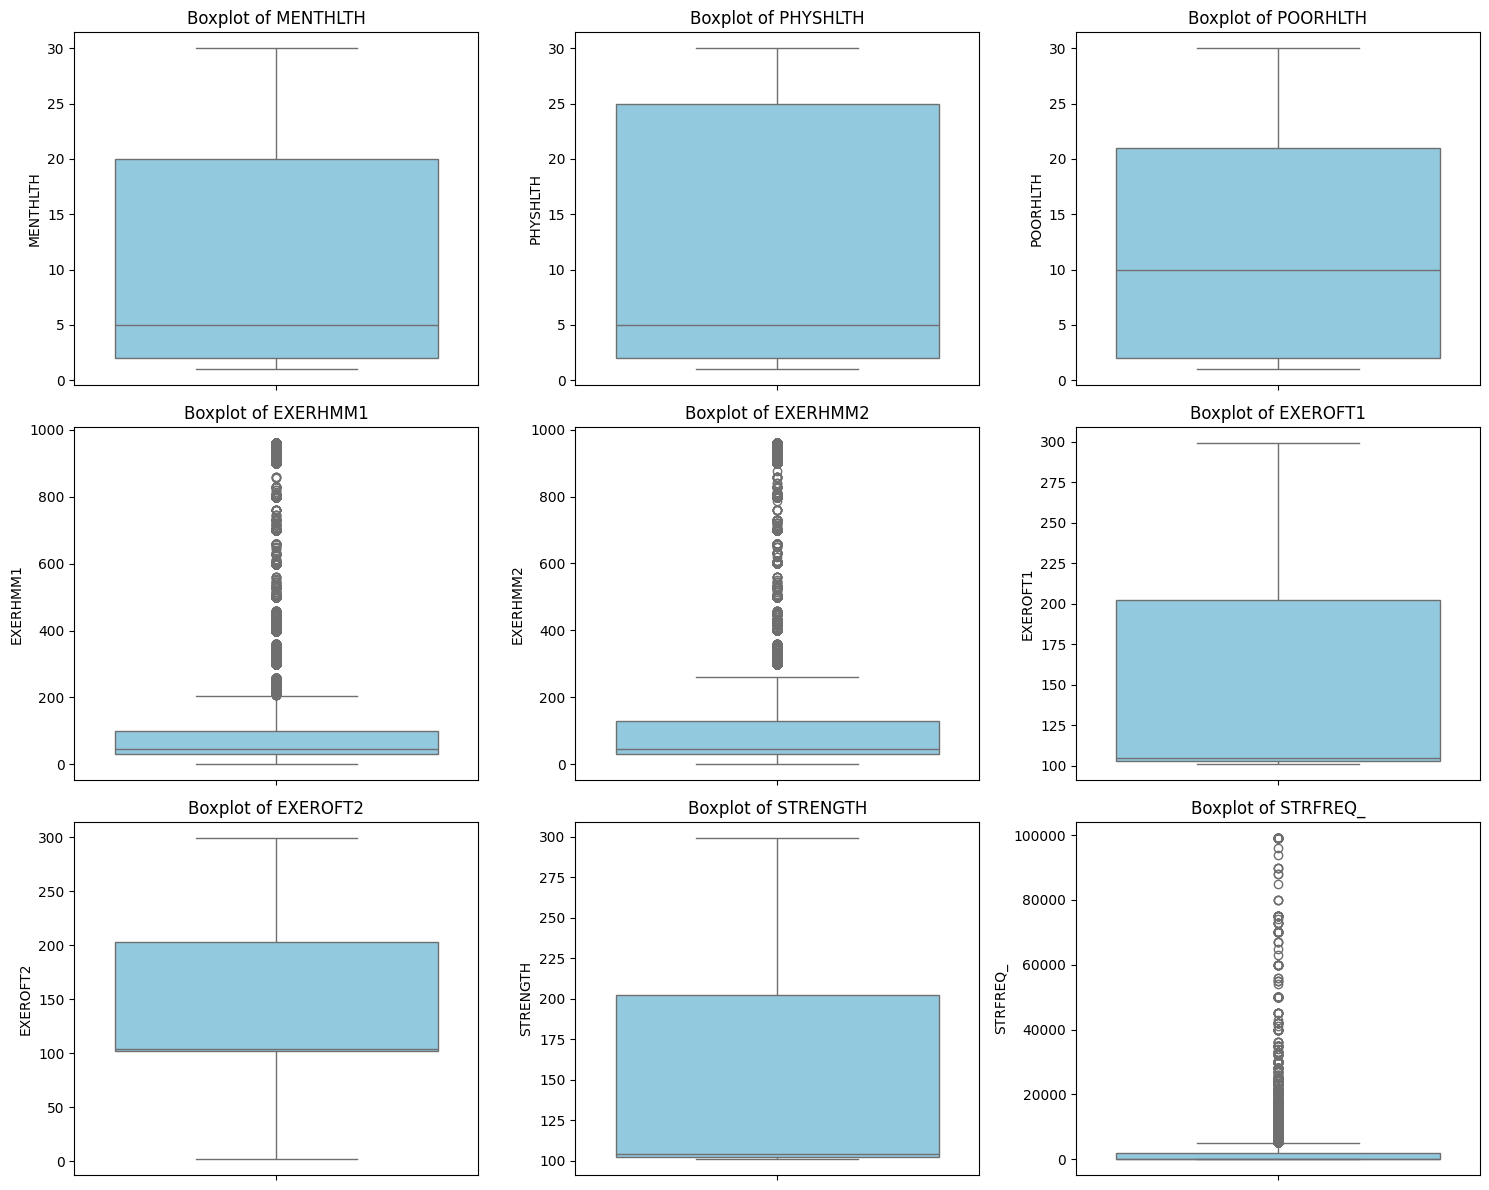

In [3]:
# --- Imports ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Load dataset ---
df = pd.read_csv('../data/processed/BRFSS_2_Lifestyle.csv', low_memory=False)
print(f"Dataset shape: {df.shape}")

# --- Column Groups ---
age_cols = ['_AGEG5YR', '_AGE65YR', '_AGE_G']
cv_cols = ['CVDINFR4', 'CVDCRHD4', 'CVDSTRK3']
health_cols = ['GENHLTH', 'MENTHLTH', 'PHYSHLTH', 'POORHLTH', 'QLACTLM2', 'ADDEPEV2', 'ASTHMA3', 'HAVARTH3']
condition_cols = ['BPHIGH4', 'BPMEDS', 'TOLDHI2', 'CHCKIDNY']
screening_cols = ['BLOODCHO', 'CHOLCHK', '_RFCHOL', '_CHOLCHK', 'PNEUVAC3']
care_cols = ['HLTHPLN1', 'PERSDOC2', 'MEDCOST', 'CHECKUP1', '_HCVU651']
pa_cols = ['_TOTINDA', 'EXERANY2', 'EXERHMM1', 'EXERHMM2', '_PASTRNG', 'EXEROFT1', 'EXEROFT2', 'STRENGTH', 'STRFREQ_']

all_cols = age_cols + cv_cols + health_cols + condition_cols + screening_cols + care_cols + pa_cols

# --- Step 1: Preprocessing ---
subset_df = df[all_cols].copy()
special_codes = [7, 9, 77, 88, 99, 777, 888, 999]
subset_df.replace(special_codes, np.nan, inplace=True)

# --- Split categorical vs numerical ---
categorical_cols = [col for col in subset_df.columns if subset_df[col].nunique() < 20]
numerical_cols = [col for col in subset_df.columns if col not in categorical_cols]

# --- Step 2: Numerical Analysis ---
print("\nSummary Statistics for Numerical Columns:")
print(subset_df[numerical_cols].describe())

# IQR outlier detection
def detect_outliers_iqr(data, column):
    valid_data = data[column].dropna()
    if valid_data.empty:
        return 0, np.nan, np.nan
    Q1, Q3 = valid_data.quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    mask = (data[column] < lower) | (data[column] > upper)
    return int(mask.sum()), lower, upper

print("\nIQR Outlier Counts for Numerical Columns:")
for col in numerical_cols:
    iqr_count, lower, upper = detect_outliers_iqr(subset_df, col)
    print(f"{col}: {iqr_count} outliers (Lower: {lower:.2f}, Upper: {upper:.2f})")

# --- Step 3: Categorical Analysis ---
print("\nValue Counts for Categorical Columns:")
for col in categorical_cols:
    print(f"\n{col}:")
    counts = subset_df[col].value_counts(dropna=False)
    percentages = (counts / len(subset_df) * 100).round(2)
    result_df = pd.DataFrame({'Count': counts, 'Percentage': percentages})
    print(result_df)

## --- Step 4: Visualization Functions (updated) ---
def plot_categorical_grid(cols, n_cols=3):
    n_rows = int(np.ceil(len(cols) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
    axes = axes.flatten()

    for i, col in enumerate(cols):
        sns.countplot(
            data=subset_df,
            x=col,
            order=subset_df[col].value_counts().index,
            hue=col,        # fixes seaborn palette warning
            palette="viridis",
            legend=False,
            ax=axes[i]
        )
        axes[i].set_title(f"Distribution of {col}")
        axes[i].tick_params(axis="x", rotation=45)

    # Remove unused subplots
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()


def plot_numerical_grid(cols, n_cols=3):
    n_rows = int(np.ceil(len(cols) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
    axes = axes.flatten()

    for i, col in enumerate(cols):
        sns.boxplot(
            data=subset_df,
            y=col,
            ax=axes[i],
            color="skyblue"
        )
        axes[i].set_title(f"Boxplot of {col}")

    # Remove unused subplots
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()


# --- Step 5: Generate Plots ---
# 1. Grid countplots for categorical
plot_categorical_grid(categorical_cols, n_cols=3)

# 2. Grid boxplots for numerical
plot_numerical_grid(numerical_cols, n_cols=3)




In [6]:
import pandas as pd
import numpy as np

# Load data
df = pd.read_csv('../data/processed/BRFSS_2_Lifestyle.csv', low_memory=False)
print(f"Original dataset shape: {df.shape}")

# Define column groups (based on provided context)
age_cols = ['_AGEG5YR', '_AGE65YR', '_AGE_G']
cv_cols = ['CVDINFR4', 'CVDCRHD4', 'CVDSTRK3']
health_cols = ['GENHLTH', 'MENTHLTH', 'PHYSHLTH', 'POORHLTH', 'QLACTLM2', 'ADDEPEV2']
condition_cols = ['BPHIGH4', 'BPMEDS', 'TOLDHI2', 'CHCKIDNY']
screening_cols = ['BLOODCHO', 'CHOLCHK', '_RFCHOL', '_CHOLCHK', 'PNEUVAC3']
care_cols = ['HLTHPLN1', 'PERSDOC2', 'MEDCOST', 'CHECKUP1', '_HCVU651']
pa_cols = ['_TOTINDA', 'EXERANY2', 'EXERHMM1', 'EXERHMM2', '_PASTRNG', 'EXEROFT1', 'EXEROFT2', 'STRENGTH', 'STRFREQ_']
all_cols = age_cols + cv_cols + health_cols + condition_cols + screening_cols + care_cols + pa_cols

# Step 1: Preprocessing
subset_df = df[all_cols].copy()
special_codes = [7, 9, 77, 88, 99, 777, 888, 999]
subset_df.replace(special_codes, np.nan, inplace=True)

# Step 2: Feature Engineering

# Age Features
subset_df['age_group_consolidated'] = subset_df['_AGEG5YR'].fillna(14)  # 14 as 'unknown'
subset_df['age_group_consolidated'] = subset_df['age_group_consolidated'].replace(
    {1: '18-24', 2: '25-29', 3: '30-34', 4: '35-39', 5: '40-44', 6: '45-49', 7: '50-54', 
     8: '55-59', 9: '60-64', 10: '65-69', 11: '70-74', 12: '75-79', 13: '80+', 14: 'Unknown'}
).astype('category')
subset_df['is_senior'] = (subset_df['_AGE65YR'] == 2).astype(int)
subset_df.drop(['_AGEG5YR', '_AGE65YR', '_AGE_G'], axis=1, inplace=True)

# Cardiovascular Features
subset_df['has_any_cv_event'] = ((subset_df['CVDINFR4'] == 1) | (subset_df['CVDCRHD4'] == 1) | 
                                (subset_df['CVDSTRK3'] == 1)).astype(int)
subset_df['cv_event_count'] = ((subset_df['CVDINFR4'] == 1).astype(int) + 
                              (subset_df['CVDCRHD4'] == 1).astype(int) + 
                              (subset_df['CVDSTRK3'] == 1).astype(int))
subset_df.drop(['CVDINFR4', 'CVDCRHD4', 'CVDSTRK3'], axis=1, inplace=True)

# General Health Features
subset_df['total_poor_health_days'] = subset_df[['MENTHLTH', 'PHYSHLTH', 'POORHLTH']].fillna(0).sum(axis=1).clip(upper=30)
subset_df['has_chronic_limitation'] = (subset_df['QLACTLM2'] == 1) | (subset_df['ADDEPEV2'] == 1).astype(int)
subset_df['gen_health_binned'] = pd.cut(subset_df['GENHLTH'], bins=[0, 2, 3, 5], 
                                       labels=['Excellent/Very Good', 'Good', 'Fair/Poor'], include_lowest=True)
subset_df.drop(['MENTHLTH', 'PHYSHLTH', 'POORHLTH', 'QLACTLM2', 'ADDEPEV2', 'GENHLTH'], 
               axis=1, inplace=True)

# Condition Features
def hyp_status(row):
    if row['BPHIGH4'] == 3: return 0  # No
    elif row['BPHIGH4'] == 2: return 1  # Pre
    elif row['BPHIGH4'] == 1 and row['BPMEDS'] == 1: return 3  # With meds
    elif row['BPHIGH4'] == 1: return 2  # No meds
    else: return np.nan
subset_df['hypertension_status'] = subset_df.apply(hyp_status, axis=1)
subset_df['has_high_cholesterol_or_kidney'] = ((subset_df['TOLDHI2'] == 1) | 
                                             (subset_df['CHCKIDNY'] == 1)).astype(int)
subset_df.drop(['BPHIGH4', 'BPMEDS', 'TOLDHI2', 'CHCKIDNY'], axis=1, inplace=True)

# Screening and Care Features
subset_df['cholesterol_screen_compliance'] = ((subset_df['_RFCHOL'] == 1) & 
                                            (subset_df['_CHOLCHK'] == 1)).astype(int)
access_cols = ['HLTHPLN1', 'PERSDOC2']
no_barrier_cols = ['MEDCOST']
recent_check_cols = ['CHECKUP1', '_HCVU651']
subset_df['healthcare_access_score'] = (
    (subset_df[access_cols] == 1).sum(axis=1) +
    (subset_df[no_barrier_cols] == 2).sum(axis=1) +
    (subset_df[recent_check_cols] == 1).sum(axis=1)
)
subset_df['has_pneumo_vac'] = (subset_df['PNEUVAC3'] == 1).astype(int)
subset_df.drop(['BLOODCHO', 'CHOLCHK', '_RFCHOL', '_CHOLCHK', 'PNEUVAC3', 'HLTHPLN1', 'PERSDOC2', 
                'MEDCOST', 'CHECKUP1', '_HCVU651'], axis=1, inplace=True)

# Physical Activity Features
subset_df['total_exercise_minutes'] = subset_df[['EXERHMM1', 'EXERHMM2']].fillna(0).sum(axis=1).clip(upper=600)
subset_df['strength_training_freq'] = subset_df['STRFREQ_'] / 1000  # Normalize to days/week
subset_df['strength_training_freq'] = subset_df['strength_training_freq'].clip(upper=7)  # Max 7 days/week
subset_df['meets_pa_guidelines'] = ((subset_df['_TOTINDA'] == 1) & (subset_df['_PASTRNG'] == 1)).astype(int)
subset_df.drop(['_TOTINDA', 'EXERANY2', 'EXERHMM1', 'EXERHMM2', '_PASTRNG', 'EXEROFT1', 'EXEROFT2', 
                'STRENGTH', 'STRFREQ_'], axis=1, inplace=True)

# Step 3: Merge engineered features back to original dataset
df_final = df.drop(all_cols, axis=1, errors='ignore').join(subset_df)

# Step 4: Save the updated dataset
updated_path = '../data/processed/BRFSS_3_Health.csv'
df_final.to_csv(updated_path, index=False)
print(f"\nSaved dataset to: {updated_path}")
print(f"Total columns retained: {len(df_final.columns)}")
print(f"Final shape: {df_final.shape}")

Original dataset shape: (1439696, 184)

Saved dataset to: ../data/processed/BRFSS_3_Health.csv
Total columns retained: 164
Final shape: (1439696, 164)


In [4]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('../data/processed/BRFSS_2_Lifestyle.csv', low_memory=False)
print(f"Original dataset shape: {df.shape}")

# Define column groups for feature engineering
# Age / demographics
age_cols = ['_AGEG5YR', '_AGE65YR', '_AGE_G']

# Cardiovascular conditions
cv_cols = ['CVDINFR4', 'CVDCRHD4', 'CVDSTRK3']

# General & mental health, chronic disease status
# Expanded based on your full list — include only those you want to engineer from
health_cols = [
    'GENHLTH', 'MENTHLTH', 'PHYSHLTH', 
    
]

# Condition awareness & medication (only BPHIGH4 used for hypertension)
bp_cols = ['BPHIGH4']  # others like BPMEDS, TOLDHI2 kept raw unless engineered

# Physical activity / lifestyle
pa_cols = ['_TOTINDA', 'EXERANY2', 'EXERHMM1', 'EXERHMM2', '_PASTRNG']

# Combine all needed cols for engineering
eng_cols = age_cols + cv_cols + health_cols + pa_cols + bp_cols
existing_eng_cols = [col for col in eng_cols if col in df.columns]
df_subset = df[existing_eng_cols].copy()

# Preserve all other columns (including unused health/condition/screening columns)
df_other = df.drop(columns=existing_eng_cols)

# --- Preprocess: Replace BRFSS special codes with NaN ---
special_codes = [7, 9, 77, 88, 99, 777, 888, 999]
df_subset.replace(special_codes, np.nan, inplace=True)

# --- Optional: Clean implausible exercise minutes in df_other (for data integrity) ---
# Even if not used in modeling, this prevents future confusion
exercise_min_cols = ['EXERHMM1', 'EXERHMM2']
for col in exercise_min_cols:
    if col in df_other.columns:
        # Cap at 600 minutes/week (~85 min/day) — reasonable upper bound
        df_other[col] = df_other[col].clip(upper=600)

# Feature Engineering 
engineered_features = []

# 1. Physical activity (from _TOTINDA: 1=active, 2=inactive)
if '_TOTINDA' in df_subset:
    df_subset['physically_active'] = df_subset['_TOTINDA'].map({1: 1, 2: 0})
    engineered_features.append('physically_active')

# 2. Muscle strengthening (from _PASTRNG: 1=yes, 2=no)
if '_PASTRNG' in df_subset:
    df_subset['meets_strength_guideline'] = df_subset['_PASTRNG'].map({1: 1, 2: 0})
    engineered_features.append('meets_strength_guideline')

# 3. Any cardiovascular disease (CVDINFR4, CVDCRHD4, CVDSTRK3: 1=yes)
cv_present = [c for c in cv_cols if c in df_subset]
if cv_present:
    df_subset['has_cvd'] = (df_subset[cv_present] == 1).any(axis=1).astype(int)
    engineered_features.append('has_cvd')

# 4. Poor general health (GENHLTH: 4=Fair, 5=Poor → 1; 1-3 → 0)
if 'GENHLTH' in df_subset:
    df_subset['poor_general_health'] = df_subset['GENHLTH'].apply(
        lambda x: 1 if x in [4, 5] else (0 if x in [1, 2, 3] else np.nan)
    ).astype('Int64')
    engineered_features.append('poor_general_health')

# 5. Frequent mental distress (MENTHLTH: ≥14 days in past 30 → 1)
if 'MENTHLTH' in df_subset:
    df_subset['frequent_mental_distress'] = df_subset['MENTHLTH'].apply(
        lambda x: 1 if pd.notna(x) and 14 <= x <= 30 else (0 if pd.notna(x) and 0 <= x < 14 else np.nan)
    ).astype('Int64')
    engineered_features.append('frequent_mental_distress')

# 6. Frequent physical distress (PHYSHLTH: ≥14 days → 1)
if 'PHYSHLTH' in df_subset:
    df_subset['frequent_physical_distress'] = df_subset['PHYSHLTH'].apply(
        lambda x: 1 if pd.notna(x) and 14 <= x <= 30 else (0 if pd.notna(x) and 0 <= x < 14 else np.nan)
    ).astype('Int64')
    engineered_features.append('frequent_physical_distress')

# 7. Hypertension (BPHIGH4):
#   1 = Yes (true hypertension)
#   2 = Yes, but only during pregnancy → NOT true HTN → 0
#   3 = No
#   4 = Borderline high → treated as No (standard for binary outcome)
if 'BPHIGH4' in df_subset:
    df_subset['has_hypertension'] = df_subset['BPHIGH4'].map({
        1: 1,
        2: 0,
        3: 0,
        4: 0
    }).astype('Int64')
    engineered_features.append('has_hypertension')

# 8. CDC-aligned age groups
def create_cdc_age_groups(df, ageg5yr_col='_AGEG5YR', age_g_col='_AGE_G', age65yr_col='_AGE65YR'):
    age_group = pd.Series(np.nan, index=df.index, dtype='float64')

    # Map _AGEG5YR to 6 CDC groups
    ageg5yr_to_group = {
        1: 1,   # 18–24
        2: 2, 3: 2,   # 25–34
        4: 3, 5: 3,   # 35–44
        6: 4, 7: 4,   # 45–54
        8: 5, 9: 5,   # 55–64
        10: 6, 11: 6, 12: 6, 13: 6  # 65+
    }

    if ageg5yr_col in df:
        mask = df[ageg5yr_col].notna()
        age_group[mask] = df.loc[mask, ageg5yr_col].map(ageg5yr_to_group)

    # Fallback to _AGE_G if available and age_group still missing
    if age_g_col in df:
        mask = age_group.isna() & df[age_g_col].notna()
        age_group[mask] = df.loc[mask, age_g_col]

    # Use _AGE65YR to identify seniors (code 2 = 65+)
    if age65yr_col in df:
        mask_senior = age_group.isna() & (df[age65yr_col] == 2)
        age_group[mask_senior] = 6

    return age_group.astype('Int64')

if any(col in df_subset for col in age_cols):
    df_subset['age_group'] = create_cdc_age_groups(df_subset)
    engineered_features.append('age_group')

# Drop raw engineered columns 
raw_cols_to_drop = eng_cols
cols_to_drop = [col for col in raw_cols_to_drop if col in df_subset]
df_subset.drop(columns=cols_to_drop, inplace=True)

# Merge engineered features back with untouched data
df_final = pd.concat([df_other, df_subset], axis=1)

print(f"\nDropped {len(cols_to_drop)} raw feature columns.")
print(f"Engineered {len(engineered_features)} features: {engineered_features}")
print(f"Final dataset shape: {df_final.shape}")

# Sanity check: missingness in engineered features
print("\nMissing values in engineered features:")
missing_engineered = df_final[engineered_features].isna().sum().sort_values(ascending=False)
print(missing_engineered)

# Visualize engineered features
sns.set_style("whitegrid")
n_features = len(engineered_features)
if n_features:
    n_cols = 3
    n_rows = (n_features + n_cols - 1) // n_cols
    plt.figure(figsize=(5 * n_cols, 4 * n_rows))
    for i, feat in enumerate(engineered_features, 1):
        plt.subplot(n_rows, n_cols, i)
        # Drop NaN for plotting
        plot_data = df_final[feat].dropna()
        if plot_data.empty:
            plt.title(f"{feat.replace('_', ' ').title()} (No Data)")
            continue
        sns.countplot(x=plot_data, hue=plot_data, palette='Set2', legend=False)
        plt.title(feat.replace("_", " ").title())
        plt.xlabel('')
        if feat in ['physically_active','meets_strength_guideline','has_cvd',
                    'poor_general_health','frequent_mental_distress',
                    'frequent_physical_distress','has_hypertension']:
            plt.gca().set_xticks([0, 1])
            plt.gca().set_xticklabels(['No','Yes'])
        elif feat == 'age_group':
            plt.gca().set_xticks([1,2,3,4,5,6])
            plt.gca().set_xticklabels(['18-24','25-34','35-44','45-54','55-64','65+'], rotation=45)
        total = len(plot_data)
        for p in plt.gca().patches:
            if total > 0 and not np.isnan(p.get_height()):
                perc = f'{100 * p.get_height()/total:.1f}%'
                plt.gca().annotate(perc, (p.get_x()+p.get_width()/2., p.get_height()),
                                   ha='center', va='bottom', fontsize=10)
    plt.tight_layout()
    plt.show()

# ave updated dataset
updated_path = '../data/processed/BRFSS_3_Health.csv'
df_final.to_csv(updated_path, index=False)
print(f"\nSaved dataset to: {updated_path}")
print(f"Total columns retained: {len(df_final.columns)}")

Original dataset shape: (1439696, 184)


KeyboardInterrupt: 

In [6]:
# Load CSV file 
df = pd.read_csv('../data/processed/BRFSS_3_Health.csv')

# Show dataset dimensions
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

# Show feature (column) names
print("\nFeature names (columns):")
print(df.columns.tolist())

# Show first 5 rows of the dataset
print("\nFirst 5 rows of the dataset:")
print(df.head())

# Show dataset info 
print("\nDataset Info:")
print(df.info())


Number of rows: 1439696
Number of columns: 177

Feature names (columns):
['_WT2RAKE', 'FMONTH', 'USEEQUIP', 'CADULT', 'LASTSIG3', 'BLDSUGAR', 'HOWLONG', 'PDIABTST', 'QSTVER', 'HADSIGM3', 'QLACTLM2', 'DIABETE3', 'RCSRLTN2', 'NUMMEN', 'IMFVPLAC', 'FEETCHK2', 'VETERAN3', 'PREDIAB1', 'SEQNO', 'MISTMNT', 'QLSTRES2', 'CASTHDX2', 'DISPCODE', 'CASTHNO2', 'CHCOCNCR', 'SCNTPAID', 'CTELNUM1', 'SEATBELT', 'INSULIN', 'LSTBLDS3', '_STATE', 'CELLFON2', 'PVTRESD2', 'MSCODE', '_PSU', '_CHLDCNT', 'HADHYST2', 'EMTSUPRT', 'PADUR2_', 'BPMEDS', '_CLLCPWT', 'IMONTH', '_LLCPWT', 'BLDSTOOL', 'CHILDREN', '_RFSEAT2', '_INCOMG', 'HIVTSTD3', 'DIABEYE', 'USENOW3', 'ASTHNOW', 'FLSHTMY2', 'ASERVIST', 'QLMENTL2', 'LMTJOIN3', 'SEX', 'DIABEDU', 'PREGNANT', '_PNEUMO2', 'TOLDHI2', 'HIVTST6', 'JOINPAIN', 'PNEUVAC3', '_RFHYPE5', '_RAWRAKE', 'FC60_', 'IYEAR', '_MISVEGN', 'CHCKIDNY', 'MEDCOST', 'CVDASPRN', 'ASNOSLEP', 'MARITAL', 'ASTHMED3', '_LTASTH1', 'ASPUNSAF', '_RFCHOL', 'NUMADULT', '_AIDTST3', 'PADUR1_', 'EDUCA', '_STSTR

## Behavioral Factors

Loaded dataset with 1439696 rows and 177 columns.
Numerical columns (10): ['ASTHMAGE', 'ASACTLIM', 'ASDRVIST', 'ASERVIST', 'ASRCHKUP', 'HIVTSTD3', 'EXEROFT1', 'EXEROFT2', 'STRENGTH', 'STRFREQ_']
Categorical columns (30): ['ARTHDIS2', 'ARTHEDU', 'ARTHEXER', 'ARTHSOCL', 'ARTHWGT', 'ARTTODAY', 'ASTHMED3', 'ASTHNOW', 'ASYMPTOM', 'ASATTACK', 'ASINHALR', 'ASNOSLEP', 'ASPUNSAF', 'PROFEXAM', 'PSATEST1', 'PSATIME', 'HADMAM', 'HADPAP2', 'HADSGCO1', 'HADHYST2', 'LASTPAP2', 'LASTSIG3', 'LASTSMK2', 'LENGEXAM', 'HIVTST6', '_AIDTST3', 'INCOME2', '_INCOMG', 'EDUCA', '_EDUCAG']

Summary Statistics for Numerical Columns:
          ASTHMAGE     ASACTLIM    ASDRVIST    ASERVIST     ASRCHKUP  \
count  3032.000000  1750.000000  433.000000  300.000000  1179.000000   
mean     62.324868   661.185714    9.981524    4.556667     8.811705   
std      32.781849   380.809320   25.029975   14.484917    23.021364   
min      11.000000     1.000000    1.000000    1.000000     1.000000   
25%      30.000000   127.5000

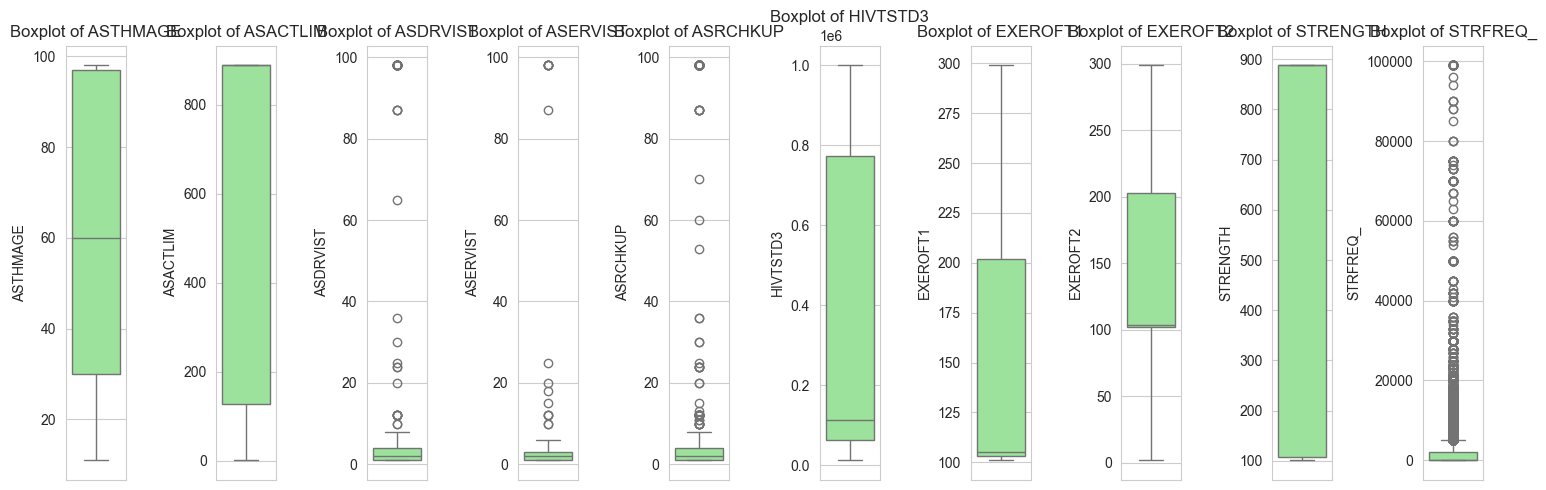

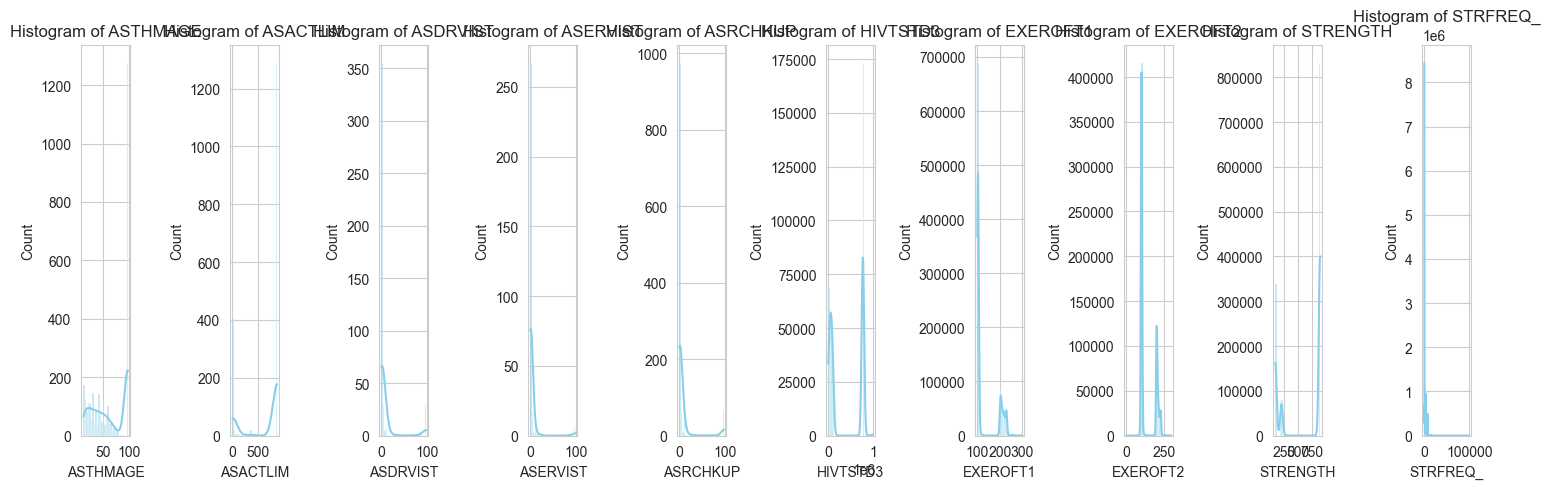

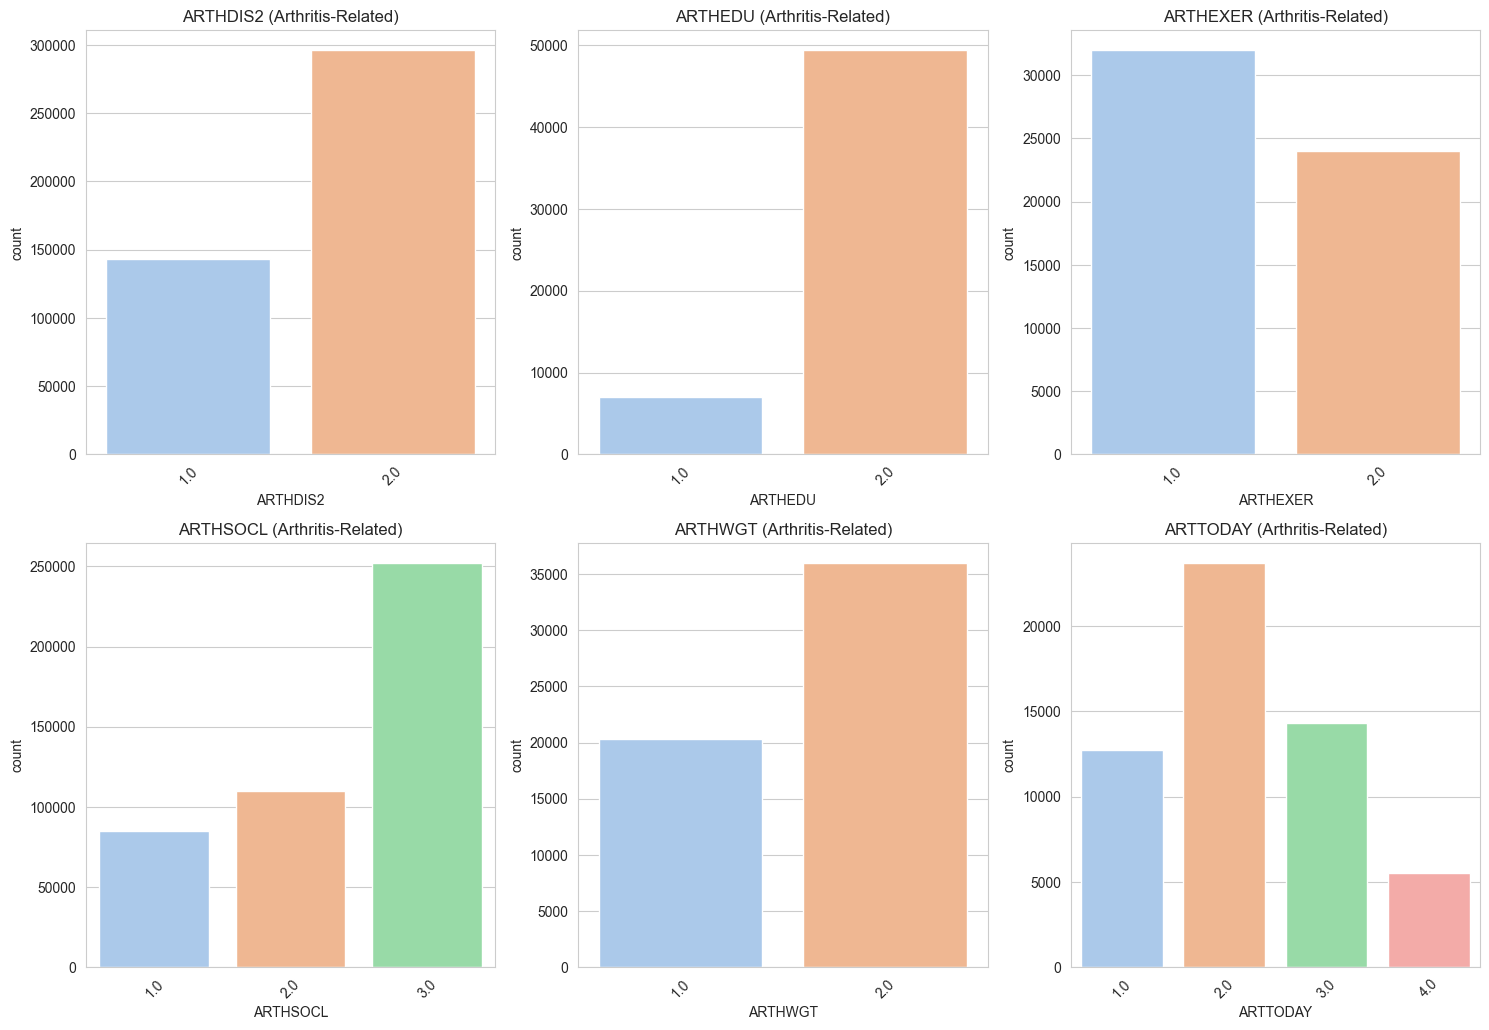

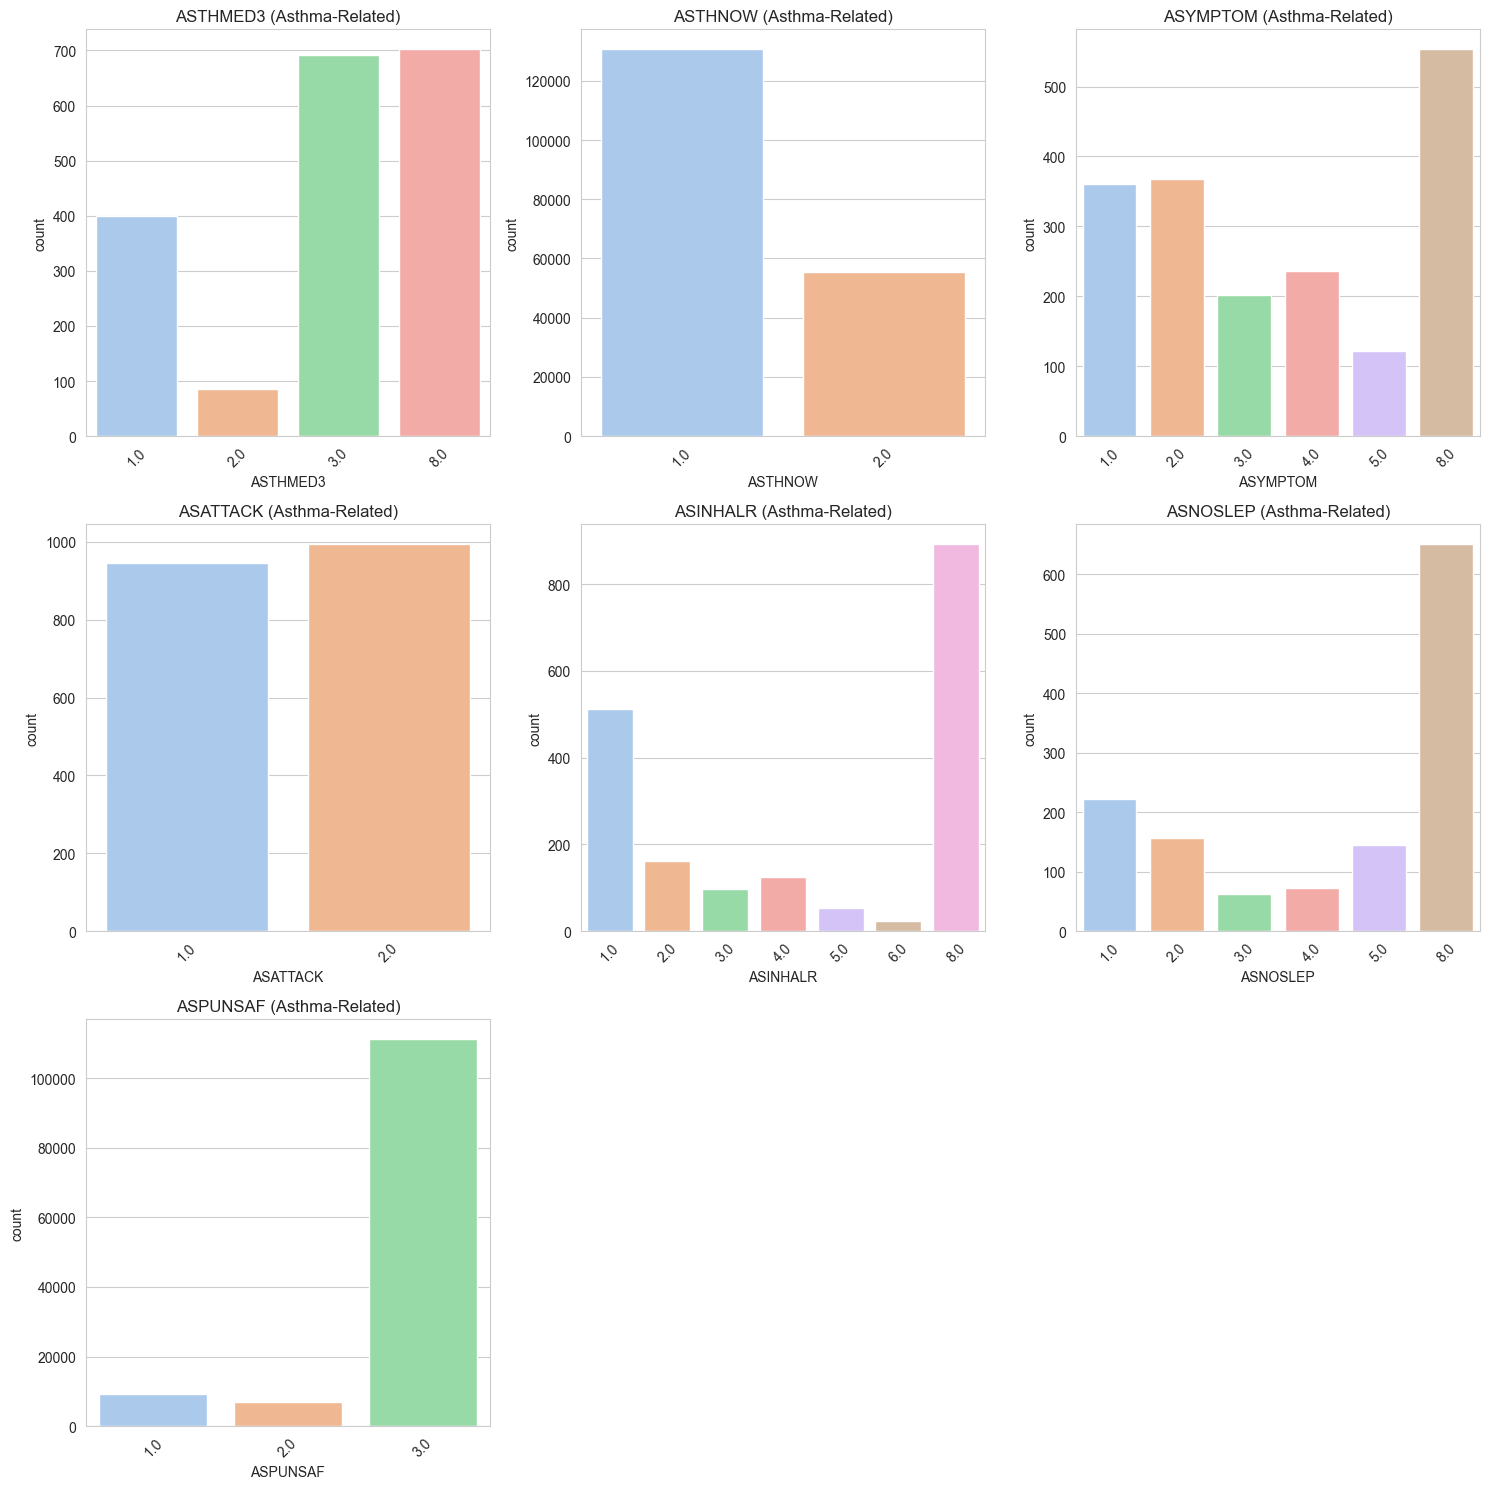

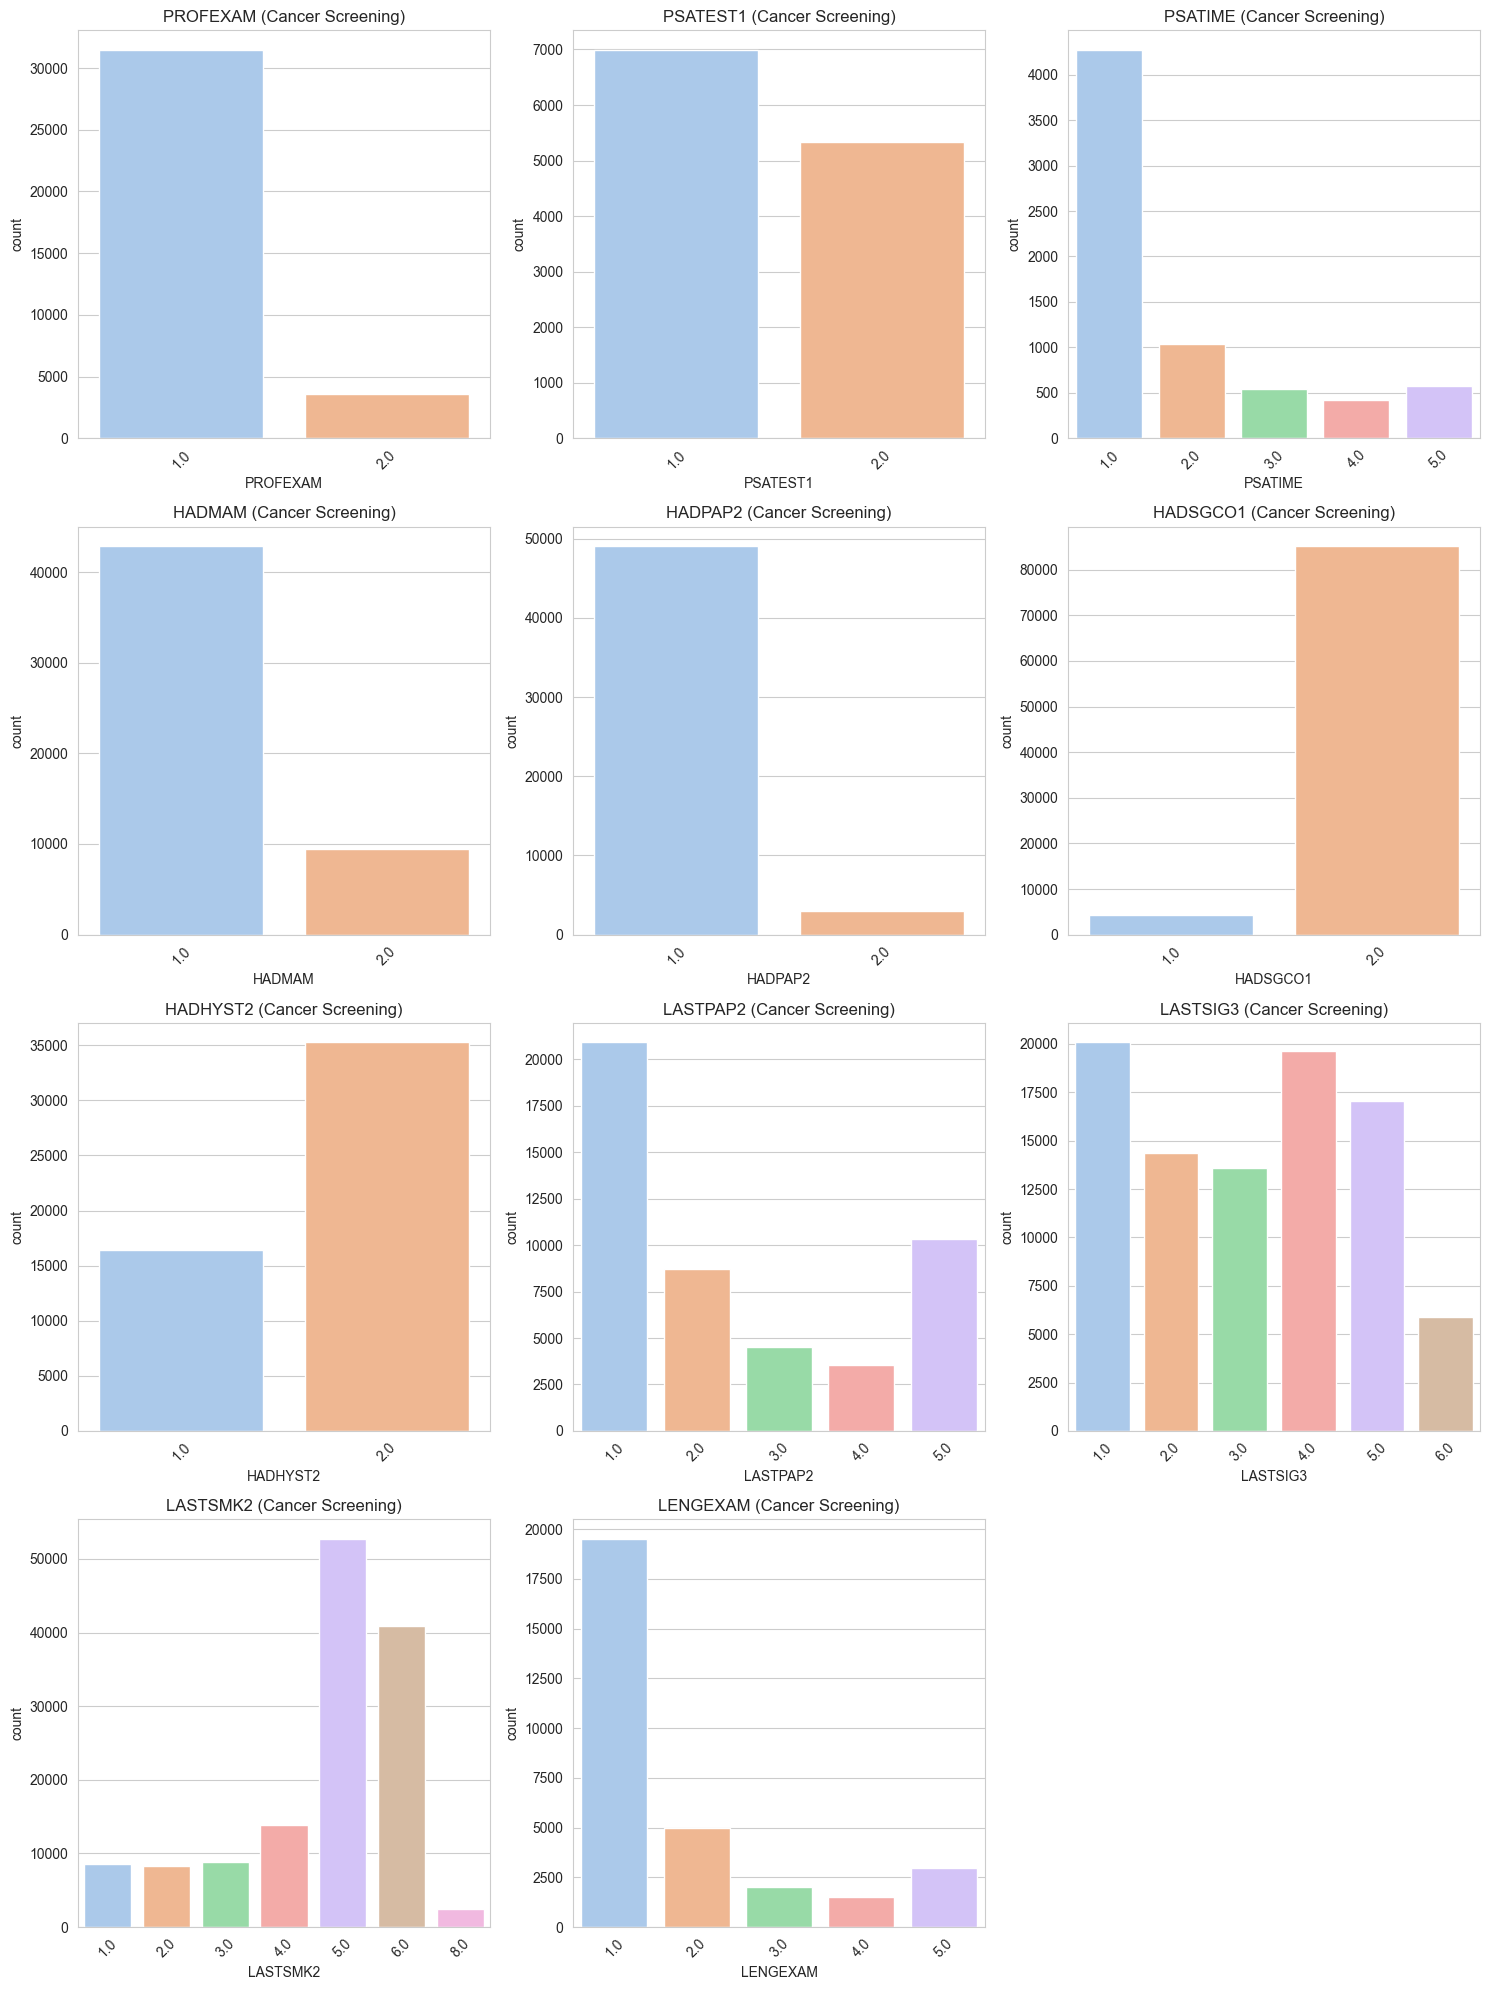

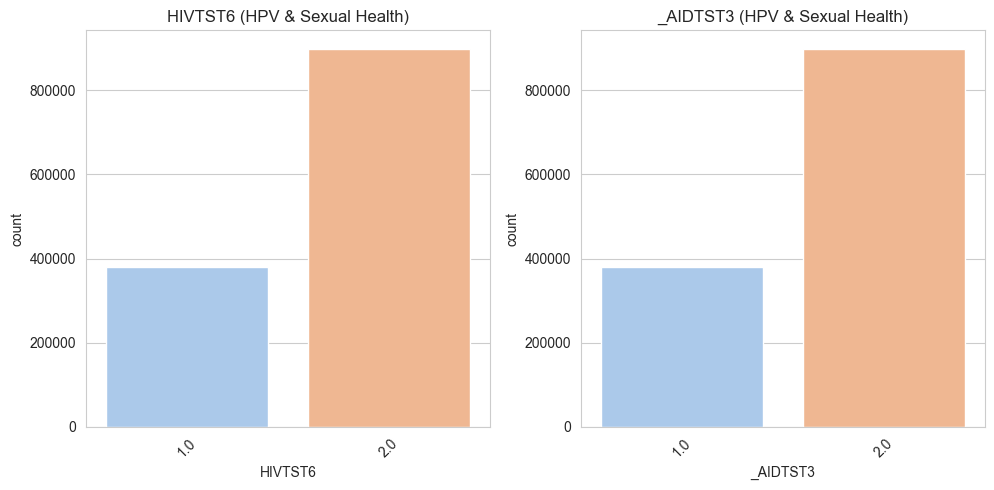

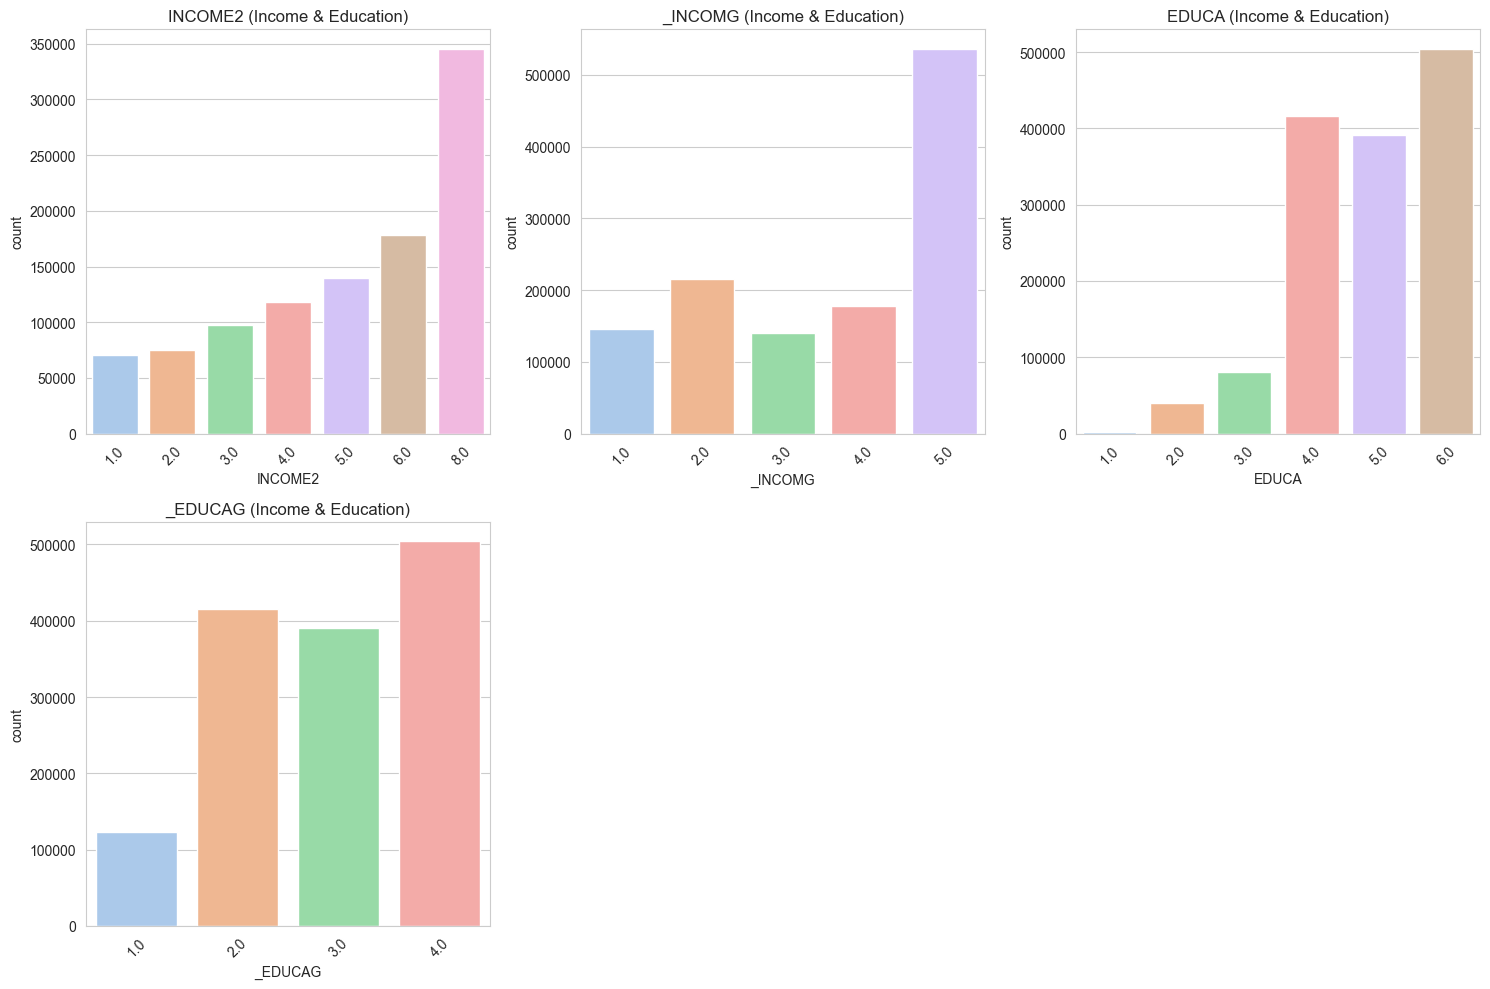

In [ ]:
# Load dataset
df = pd.read_csv('../data/processed/BRFSS_3_Health.csv', low_memory=False)
print(f"Loaded dataset with {df.shape[0]} rows and {df.shape[1]} columns.")

# Define column groups
arthritis_cols = ['ARTHDIS2', 'ARTHEDU', 'ARTHEXER', 'ARTHSOCL', 'ARTHWGT', 'ARTTODAY']
asthma_cols = ['ASTHMAGE', 'ASTHMED3', 'ASTHNOW', 'ASYMPTOM', 'ASACTLIM', 'ASATTACK',
               'ASDRVIST', 'ASERVIST', 'ASINHALR', 'ASNOSLEP', 'ASPUNSAF', 'ASRCHKUP']
cancer_screening_cols = ['PROFEXAM', 'PSATEST1', 'PSATIME', 'HADMAM', 'HADPAP2', 'HADSGCO1',
                         'HADHYST2', 'LASTPAP2', 'LASTSIG3', 'LASTSMK2', 'LENGEXAM']
hpv_sexual_health_cols = ['HIVTST6', 'HIVTSTD3', '_AIDTST3']
physical_activity_cols = [ 'EXEROFT1', 'EXEROFT2',
                            'STRENGTH', 'STRFREQ_']
income_education_cols = ['INCOME2', '_INCOMG',]
education_cols = ['EDUCA', '_EDUCAG']

# Combine all columns
all_cols = (arthritis_cols + asthma_cols + cancer_screening_cols + hpv_sexual_health_cols + 
            physical_activity_cols + income_education_cols)

# Subset the dataset
subset_df = df[all_cols].copy()

# Step 1: Preprocess columns
# Replace BRFSS special codes with NaN (e.g., 7, 9, 77, 88, 99, 777, 999)
special_codes = [7, 9, 77, 88, 99, 777, 999]
for col in all_cols:
    subset_df[col] = subset_df[col].replace(special_codes, np.nan)

# Identify numerical columns (likely continuous or ordinal with >10 unique values)
numerical_cols = []
categorical_cols = []
for col in all_cols:
    unique_vals = subset_df[col].dropna().nunique()
    if unique_vals > 10:  # Threshold for numerical
        numerical_cols.append(col)
    else:
        categorical_cols.append(col)

print(f"Numerical columns ({len(numerical_cols)}): {numerical_cols}")
print(f"Categorical columns ({len(categorical_cols)}): {categorical_cols}")

# Convert categorical columns to category dtype
for col in categorical_cols:
    subset_df[col] = subset_df[col].astype('category')

# Step 2: Numerical Analysis
# Summary statistics for numerical columns
print("\nSummary Statistics for Numerical Columns:")
print(subset_df[numerical_cols].describe())

# Outlier detection using IQR for numerical columns
def detect_outliers_iqr(data, column):
    valid_data = data[column].dropna()
    Q1 = valid_data.quantile(0.25)
    Q3 = valid_data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    mask = (data[column] < lower_bound) | (data[column] > upper_bound)
    return len(data.loc[mask, column]), lower_bound, upper_bound

print("\nIQR Outlier Counts for Numerical Columns:")
for col in numerical_cols:
    iqr_count, lower, upper = detect_outliers_iqr(subset_df, col)
    print(f"{col}: {iqr_count} outliers (Lower: {lower:.2f}, Upper: {upper:.2f})")

# Value Counts for Categorical Columns (top 10 values + NaN)
print("\nValue Counts for Categorical Columns:")
for col in categorical_cols:
    print(f"\n{col}:")
    counts = subset_df[col].value_counts(dropna=False).head(10)
    percentages = (counts / len(subset_df) * 100).round(2)
    print(pd.DataFrame({'Count': counts, 'Percentage': percentages}))

# Step 3: Visualizations
sns.set_style("whitegrid")

# Boxplots for numerical columns
if numerical_cols:
    plt.figure(figsize=(15, 5))
    for i, col in enumerate(numerical_cols, 1):
        plt.subplot(1, len(numerical_cols), i)
        sns.boxplot(y=subset_df[col], color='lightgreen')
        plt.title(f'Boxplot of {col}')
        plt.ylabel(col)
    plt.tight_layout()
    plt.show()

# Histograms for numerical columns
if numerical_cols:
    plt.figure(figsize=(15, 5))
    for i, col in enumerate(numerical_cols, 1):
        plt.subplot(1, len(numerical_cols), i)
        sns.histplot(subset_df[col].dropna(), bins=30, kde=True, color='skyblue')
        plt.title(f'Histogram of {col}')
        plt.xlabel(col)
    plt.tight_layout()
    plt.show()

# Count plots for categorical columns (grouped by category to avoid overcrowding)
categories = {
    'Arthritis-Related': arthritis_cols,
    'Asthma-Related': asthma_cols,
    'Cancer Screening': cancer_screening_cols,
    'HPV & Sexual Health': hpv_sexual_health_cols,
    'Physical Activity': physical_activity_cols,
    'Income & Education': income_education_cols
}

for group_name, group_cols in categories.items():
    group_cat_cols = [col for col in group_cols if col in categorical_cols]
    if group_cat_cols:
        n_cols = len(group_cat_cols)
        plt.figure(figsize=(15, 5 * (n_cols // 3 + 1)))
        for i, col in enumerate(group_cat_cols, 1):
            plt.subplot((n_cols // 3 + 1), 3, i)
            sns.countplot(x=subset_df[col], hue=subset_df[col], palette='pastel', legend=False)
            plt.title(f'{col} ({group_name})')
            plt.xlabel(col)
            plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

In [15]:
# --- Imports ---
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# --- Load dataset ---
df = pd.read_csv('../data/processed/BRFSS_3_Health.csv', low_memory=False)
print(f"Loaded dataset with {df.shape[0]} rows and {df.shape[1]} columns.")

# --- Define column groups ---
arthritis_cols = ['ARTHDIS2', 'ARTHEDU', 'ARTHEXER', 'ARTHSOCL', 'ARTHWGT', 'ARTTODAY']
asthma_cols = ['ASTHMAGE', 'ASTHMED3', 'ASTHNOW', 'ASYMPTOM', 'ASACTLIM', 'ASATTACK',
               'ASDRVIST', 'ASERVIST', 'ASINHALR', 'ASNOSLEP', 'ASPUNSAF', 'ASRCHKUP']
cancer_screening_cols = ['PROFEXAM', 'PSATEST1', 'PSATIME', 'HADMAM', 'HADPAP2', 'HADSGCO1',
                         'HADHYST2', 'LASTPAP2', 'LASTSIG3', 'LASTSMK2', 'LENGEXAM']
hpv_sexual_health_cols = ['HIVTST6', 'HIVTSTD3', '_AIDTST3']
physical_activity_cols = ['EXEROFT1', 'EXEROFT2', 'STRENGTH', 'STRFREQ_']
income_education_cols = ['INCOME2', '_INCOMG', 'EDUCA', '_EDUCAG']

all_cols = (arthritis_cols + asthma_cols + cancer_screening_cols + hpv_sexual_health_cols + 
            physical_activity_cols + income_education_cols)

# Keep only existing columns
all_cols = [col for col in all_cols if col in df.columns]
df_subset = df[all_cols].copy()
df_other = df.drop(columns=all_cols)

# --- Replace BRFSS special codes ---
special_codes = [7, 9, 77, 88, 99, 777, 888, 999]
df_subset.replace(special_codes, np.nan, inplace=True)

# --- FEATURE ENGINEERING (Expanded & CDC-Aligned) ---
engineered = {}

# ================================
# 1. Arthritis Features
# ================================
if 'ARTHDIS2' in df_subset:
    engineered['has_arthritis'] = df_subset['ARTHDIS2'].map({1: 1, 2: 0}).astype('Int64')

# Arthritis impact: limited in social/leisure (ARTHSOCL: 1=Not limited, 2=A little, 3=Very)
if 'ARTHSOCL' in df_subset:
    # Create: 1 = limited (codes 2 or 3), 0 = not limited (code 1)
    engineered['arthritis_limits_social'] = df_subset['ARTHSOCL'].apply(
        lambda x: 1 if x in [2, 3] else (0 if x == 1 else np.nan)
    ).astype('Int64')

# ================================
# 2. Asthma Features
# ================================
if 'ASTHNOW' in df_subset:
    engineered['has_current_asthma'] = df_subset['ASTHNOW'].map({1: 1, 2: 0}).astype('Int64')

if 'ASATTACK' in df_subset:
    engineered['had_asthma_attack'] = df_subset['ASATTACK'].map({1: 1, 2: 0}).astype('Int64')

if 'ASINHALR' in df_subset:
    engineered['uses_asthma_medication'] = df_subset['ASINHALR'].map({1: 1, 2: 0}).astype('Int64')

# Asthma control: symptom frequency (ASPUNSAF)
# 1=Daily, 2=Weekly, 3=Monthly or less → Poor control = daily/weekly
if 'ASPUNSAF' in df_subset:
    engineered['poor_asthma_control'] = df_subset['ASPUNSAF'].apply(
        lambda x: 1 if x in [1, 2] else (0 if x == 3 else np.nan)
    ).astype('Int64')

# ================================
# 3. Cancer Screening Recency
# ================================
# LASTPAP2: 1=Within past year, 2=1-2 years, 3=2-3 years, 4=3-5 years, 5=5+ years
if 'LASTPAP2' in df_subset:
    engineered['pap_test_recent'] = df_subset['LASTPAP2'].apply(
        lambda x: 1 if x in [1, 2, 3] else (0 if x in [4, 5] else np.nan)  # within 3 years
    ).astype('Int64')

# LASTSIG3: Colonoscopy recency (1=Within past year, ..., 6=Never)
if 'LASTSIG3' in df_subset:
    engineered['colonoscopy_recent'] = df_subset['LASTSIG3'].apply(
        lambda x: 1 if x in [1, 2, 3, 4, 5] else (0 if x == 6 else np.nan)  # ever had
    ).astype('Int64')

# ================================
# 4. Physical Activity (Improved)
# ================================
def freq_code_to_days(code):
    """Convert BRFSS frequency code (e.g., 103) to days/week"""
    if pd.isna(code):
        return np.nan
    try:
        return int(str(int(code))[-1])
    except:
        return np.nan

if 'EXEROFT1' in df_subset:
    days_mod = df_subset['EXEROFT1'].apply(freq_code_to_days)
    engineered['meets_moderate_pa'] = (days_mod >= 5).astype('Int64')  # CDC: ≥5 days

if 'EXEROFT2' in df_subset:
    days_vig = df_subset['EXEROFT2'].apply(freq_code_to_days)
    engineered['meets_vigorous_pa'] = (days_vig >= 3).astype('Int64')  # CDC: ≥3 days

if 'STRENGTH' in df_subset:
    days_str = df_subset['STRENGTH'].apply(freq_code_to_days)
    engineered['meets_strength_guideline'] = (days_str >= 2).astype('Int64')

# ================================
# 5. Income & Education (Detailed Tiers)
# ================================
# INCOME2: 1=<$15k, 2=$15-25k, 3=$25-35k, 4=$35-50k, 5=$50-75k, 6=$75-100k, 7=$100-150k, 8=≥$150k
if 'INCOME2' in df_subset:
    engineered['low_income'] = df_subset['INCOME2'].apply(
        lambda x: 1 if x in [1, 2] else (0 if x in [3, 4, 5, 6, 7, 8] else np.nan)
    ).astype('Int64')
    # Optional: create ordinal income group
    engineered['income_group'] = df_subset['INCOME2'].astype('Int64')

# EDUCA: 1=Never attended, 2=Grades 1-8, 3=Grades 9-11, 4=Grade 12, 5=Some college, 6=College grad
if 'EDUCA' in df_subset:
    engineered['less_than_college'] = df_subset['EDUCA'].apply(
        lambda x: 1 if x in [1, 2, 3, 4, 5] else (0 if x == 6 else np.nan)
    ).astype('Int64')
    engineered['education_level'] = df_subset['EDUCA'].astype('Int64')

# ================================
# 6. Sexual Health
# ================================
if 'HIVTST6' in df_subset:
    engineered['ever_tested_hiv'] = df_subset['HIVTST6'].map({1: 1, 2: 0}).astype('Int64')

# ================================
# Combine & Finalize
# ================================
df_engineered = pd.DataFrame(engineered, index=df.index)
df_final = pd.concat([df_other, df_engineered], axis=1)

print(f"\n Engineered {len(engineered)} features:")
for feat in engineered.keys():
    print(f" - {feat}")

# Save
df_final.to_csv('../data/processed/BRFSS_4_Behavioral.csv', index=False)
print(f"\n Saved to: ../data/processed/BRFSS_4_Behavioral.csv")
print(f"Final shape: {df_final.shape}")

## --- VISUALIZATIONS ---
sns.set_style("whitegrid")
engineered_cols = list(engineered.keys())

# Separate binary vs ordinal (for plotting)
binary_cols = []
ordinal_cols = []

for col in engineered_cols:
    non_null = df_final[col].dropna()
    if len(non_null) == 0:
        ordinal_cols.append(col)  # or skip; safe fallback
        continue
    if non_null.isin([0, 1]).all():
        binary_cols.append(col)
    else:
        ordinal_cols.append(col)

print(f"Binary features ({len(binary_cols)}): {binary_cols}")
print(f"Ordinal/other features ({len(ordinal_cols)}): {ordinal_cols}")

# 1. Count plots for binary features
if binary_cols:
    n = len(binary_cols)
    n_cols_plot = 3
    n_rows = (n + n_cols_plot - 1) // n_cols_plot
    plt.figure(figsize=(16, 4 * n_rows))
    for i, col in enumerate(binary_cols, 1):
        plt.subplot(n_rows, n_cols_plot, i)
        sns.countplot(data=df_final, x=col, palette='Set2')
        plt.title(col.replace('_', ' ').title())
        plt.xlabel('')
        plt.xticks([0, 1], ['No', 'Yes'])
        # Add percentages
        total = len(df_final[col].dropna())
        for p in plt.gca().patches:
            if total > 0:
                perc = f'{100 * p.get_height() / total:.1f}%'
                plt.gca().annotate(perc, (p.get_x() + p.get_width()/2., p.get_height()),
                                   ha='center', va='bottom')
    plt.tight_layout()
    plt.show()

# 2. Count plots for ordinal features (e.g., income_group, education_level)
if ordinal_cols:
    n = len(ordinal_cols)
    n_cols_plot = 3
    n_rows = (n + n_cols_plot - 1) // n_cols_plot
    plt.figure(figsize=(16, 4 * n_rows))
    for i, col in enumerate(ordinal_cols, 1):
        plt.subplot(n_rows, n_cols_plot, i)
        sns.countplot(data=df_final, x=col, palette='viridis')
        plt.title(col.replace('_', ' ').title())
        plt.xlabel(col)
        plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# 3. Box plots (example: mental distress by arthritis)
if 'frequent_mental_distress' in df_final.columns and 'has_arthritis' in df_final.columns:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df_final, x='has_arthritis', y='frequent_mental_distress')
    plt.title('Mental Distress by Arthritis Status')
    plt.xticks([0, 1], ['No Arthritis', 'Has Arthritis'])
    plt.ylabel('Frequent Mental Distress (0=No, 1=Yes)')
    plt.show()

# 4. Scatterplot: income vs education (with jitter)
if 'income_group' in df_final.columns and 'education_level' in df_final.columns:
    subset = df_final[['income_group', 'education_level']].dropna()
    if not subset.empty:
        plt.figure(figsize=(8, 6))
        x = subset['income_group'].astype(float) + np.random.normal(0, 0.1, len(subset))
        y = subset['education_level'].astype(float) + np.random.normal(0, 0.1, len(subset))
        plt.scatter(x, y, alpha=0.3, s=1)
        plt.xlabel('Income Group')
        plt.ylabel('Education Level')
        plt.title('Income vs Education (Jittered)')
        plt.grid(True)
        plt.show()


Loaded dataset with 1439696 rows and 177 columns.

 Engineered 16 features:
 - has_arthritis
 - arthritis_limits_social
 - has_current_asthma
 - had_asthma_attack
 - uses_asthma_medication
 - poor_asthma_control
 - pap_test_recent
 - colonoscopy_recent
 - meets_moderate_pa
 - meets_vigorous_pa
 - meets_strength_guideline
 - low_income
 - income_group
 - less_than_college
 - education_level
 - ever_tested_hiv

 Saved to: ../data/processed/BRFSS_4_Behavioral.csv
Final shape: (1439696, 153)


ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

## BRFSS_4_Behavioral Analysis

In [ ]:
# Load CSV file 
df = pd.read_csv('../data/processed/BRFSS_4_Behavioral.csv')

# Show dataset dimensions
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

# Show feature (column) names
print("\nFeature names (columns):")
print(df.columns.tolist())

# Show first 5 rows of the dataset
print("\nFirst 5 rows of the dataset:")
print(df.head())

# Show dataset info 
print("\nDataset Info:")
print(df.info())


Number of rows: 1439696
Number of columns: 216

Feature names (columns):
['_WT2RAKE', 'FMONTH', 'USEEQUIP', 'CADULT', 'LASTSIG3', 'BLDSUGAR', 'EXERANY2', 'HOWLONG', 'FRUTDA1_', 'PDIABTST', 'QSTVER', 'HADSIGM3', 'BPHIGH4', 'ORNGDAY_', 'QLACTLM2', 'DIABETE3', 'PHYSHLTH', 'RCSRLTN2', 'NUMMEN', 'IMFVPLAC', 'SMOKDAY2', 'FEETCHK2', 'VETERAN3', 'PREDIAB1', 'SEQNO', 'MISTMNT', 'AVEDRNK2', 'QLSTRES2', 'CASTHDX2', 'DISPCODE', 'CASTHNO2', 'CHCOCNCR', 'SCNTPAID', 'CTELNUM1', 'SEATBELT', 'INSULIN', 'WEIGHT2', 'BEANDAY_', 'LSTBLDS3', '_STATE', 'CELLFON2', 'PVTRESD2', 'MSCODE', 'GRENDAY_', '_PSU', 'DRNK3GE5', '_CHLDCNT', 'HADHYST2', 'EMTSUPRT', 'PADUR2_', 'BPMEDS', '_CLLCPWT', 'IMONTH', '_LLCPWT', 'BLDSTOOL', 'CHILDREN', '_RFSEAT2', '_INCOMG', 'HIVTSTD3', 'DIABEYE', 'USENOW3', '_TOTINDA', 'ASTHNOW', 'FLSHTMY2', 'ASERVIST', 'QLMENTL2', 'LMTJOIN3', 'SEX', 'DIABEDU', 'PREGNANT', '_PNEUMO2', '_VEGETEX', 'TOLDHI2', 'HIVTST6', 'EXERHMM2', 'JOINPAIN', 'PNEUVAC3', '_RFHYPE5', '_RAWRAKE', '_PASTRNG', 'FC60_',

## Further

Total medical features selected: 50
Available medical columns in data: 5
Numeric (continuous-like): []
Categorical: ['HLTHPLN1', 'PERSDOC2', 'MEDCOST', 'CHECKUP1', '_HCVU651']...

CATEGORICAL FEATURE SUMMARY (Top 5 values each)

HLTHPLN1:
HLTHPLN1
1    2
2    1
9    1
7    1
Name: count, dtype: int64

PERSDOC2:
PERSDOC2
1    2
2    1
9    1
7    1
Name: count, dtype: int64

MEDCOST:
MEDCOST
1    2
2    1
9    1
7    1
Name: count, dtype: int64

CHECKUP1:
CHECKUP1
1    2
2    1
9    1
7    1
Name: count, dtype: int64

_HCVU651:
_HCVU651
1    2
2    1
9    1
7    1
Name: count, dtype: int64

No numeric medical features found (common in BRFSS).

Plotting bar charts for first 6 categorical medical features...


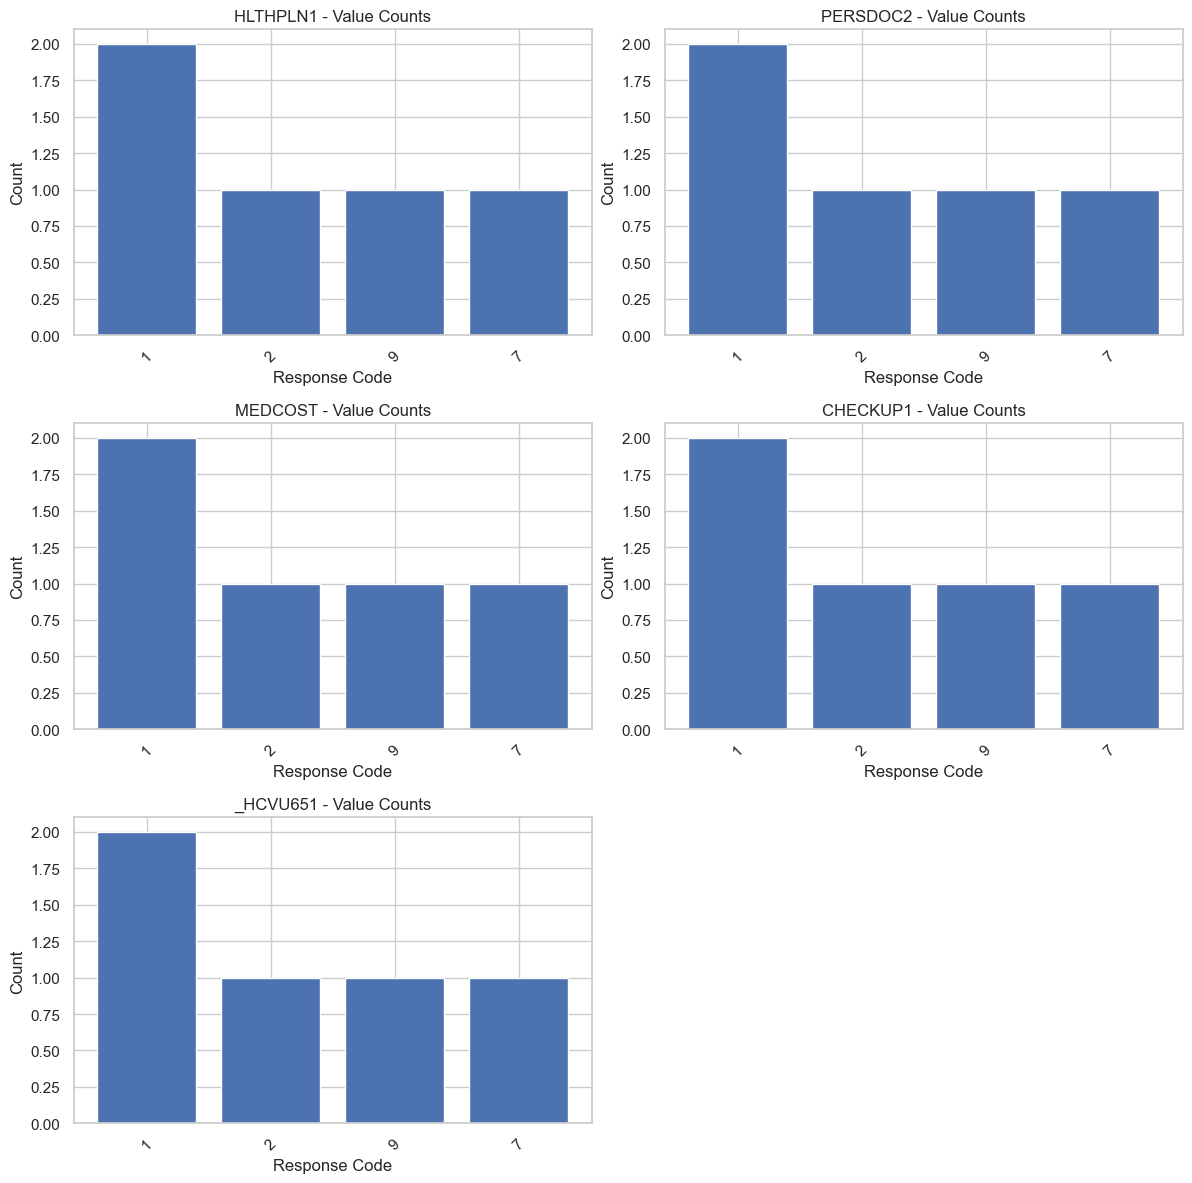


MISSING DATA IN MEDICAL FEATURES (Top 10)
          Missing Count  Missing %
HLTHPLN1              0        0.0
PERSDOC2              0        0.0
MEDCOST               0        0.0
CHECKUP1              0        0.0
_HCVU651              0        0.0


In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ---- YOUR FEATURE GROUPS (copy-paste from your message) ----
# 4. Health care access & utilization
care_cols = ['HLTHPLN1', 'PERSDOC2', 'MEDCOST', 'CHECKUP1', '_HCVU651']

# 5. Cardiovascular health
cv_cols = ['CVDASPRN', 'CASTHDX2']

# 6. Cancer
cancer_cols = ['CHCOCNCR', 'CHCSCNCR']

# 7. Diabetes
diabetes_cols = ['DIABETE3', 'PREDIAB1', 'DIABAGE2', 'DOCTDIAB', 'DIABEDU',
                 'FEETCHK2', 'FEETCHK', 'EYEEXAM', 'CHKHEMO3', 'INSULIN',
                 'BLDSUGAR', 'HOWLONG', 'PDIABTST']

# 8. Asthma
asthma_cols = ['ASTHMA3', '_CASTHM1', 'CASTHNO2', '_LTASTH1', '_ASTHMS1']

# 9. Arthritis / joint pain
arthritis_cols = ['HAVARTH3', '_DRDXAR1', 'JOINPAIN', 'LMTJOIN3', 'PAINACT2']

# 10. Cholesterol & blood pressure
bp_chol_cols = ['BPMEDS', 'TOLDHI2', 'BLOODCHO', 'CHOLCHK', '_CHOLCHK',
                '_RFCHOL', '_RFHYPE5']

# 11. Kidney disease
kidney_cols = ['CHCKIDNY']

# 12. Vaccination & preventive care
preventive_cols = ['PNEUVAC3', '_PNEUMO2', 'IMFVPLAC', 'FLSHTMY2',
                   'HPVADSHT', 'HPVADVC2']

# 14. Mental health
mental_cols = ['ADDEPEV2', 'HADSIGM3']

# 17. Functional / rehab
rehab_cols = ['HAREHAB1', 'STREHAB1']

# Combine all medical columns
medical_cols = (
    care_cols + cv_cols + cancer_cols + diabetes_cols + asthma_cols +
    arthritis_cols + bp_chol_cols + kidney_cols + preventive_cols +
    mental_cols + rehab_cols
)

# Remove duplicates (just in case)
medical_cols = list(dict.fromkeys(medical_cols))  # preserves order

print(f"Total medical features selected: {len(medical_cols)}")

# ---- LOAD YOUR DATA ----
# Replace 'your_brfss_file.csv' with your actual file path
df = pd.read_csv('../data/processed/BRFSS_4_Behavioral.csv')

# For demonstration, we'll assume df exists
# If you're running this, uncomment the line below and provide your file
# df = pd.read_csv('brfss_data.csv')

# >>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
# ⚠️  YOU NEED TO LOAD YOUR DATAFRAME HERE BEFORE PROCEEDING
# <<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<

# Example placeholder (remove when using real data):
# Let's create a tiny dummy df for syntax check only
df = pd.DataFrame({col: [1, 2, 1, 9, 7] for col in medical_cols[:5]})  # just first 5 cols

# Filter to only medical columns that exist in df
available_medical_cols = [col for col in medical_cols if col in df.columns]
print(f"Available medical columns in data: {len(available_medical_cols)}")

# Identify numeric vs categorical
# In BRFSS, truly numeric cols are rare; common ones: DIABAGE2, MAXVO2_ (but not in medical_cols above)
# We'll assume any column with dtype 'object' or 'category' is categorical,
# and int/float with low cardinality (<10 unique) is also treated as categorical.

numeric_cols = []
categorical_cols = []

for col in available_medical_cols:
    if df[col].dtype in ['float64', 'int64']:
        # Check cardinality
        uniq = df[col].nunique()
        if uniq < 10 or df[col].isnull().all():
            categorical_cols.append(col)
        else:
            numeric_cols.append(col)
    else:
        categorical_cols.append(col)

print(f"Numeric (continuous-like): {numeric_cols}")
print(f"Categorical: {categorical_cols[:10]}...")  # show first 10

# ---- 1. Summary: Value Counts for Categorical ----
print("\n" + "="*60)
print("CATEGORICAL FEATURE SUMMARY (Top 5 values each)")
print("="*60)
for col in categorical_cols[:10]:  # limit to first 10 to avoid overload
    print(f"\n{col}:")
    print(df[col].value_counts(dropna=False).head())

# ---- 2. Numeric Summary & Boxplots ----
if numeric_cols:
    print("\n" + "="*60)
    print("NUMERIC FEATURE SUMMARY")
    print("="*60)
    print(df[numeric_cols].describe())

    # Boxplots for numeric cols
    n = len(numeric_cols)
    cols = 2
    rows = (n + 1) // cols
    plt.figure(figsize=(10, 4 * rows))
    for i, col in enumerate(numeric_cols, 1):
        plt.subplot(rows, cols, i)
        plt.boxplot(df[col].dropna(), vert=True)
        plt.title(f'Boxplot: {col}')
        plt.ylabel(col)
    plt.tight_layout()
    plt.show()
else:
    print("\nNo numeric medical features found (common in BRFSS).")

# ---- 3. Categorical Bar Plots (first 6 features) ----
cat_to_plot = categorical_cols[:6]
if cat_to_plot:
    print("\nPlotting bar charts for first 6 categorical medical features...")
    n = len(cat_to_plot)
    cols = 2
    rows = (n + 1) // cols
    plt.figure(figsize=(12, 4 * rows))
    for i, col in enumerate(cat_to_plot, 1):
        plt.subplot(rows, cols, i)
        value_counts = df[col].value_counts()
        plt.bar(value_counts.index.astype(str), value_counts.values)
        plt.title(f'{col} - Value Counts')
        plt.xlabel('Response Code')
        plt.ylabel('Count')
        plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# ---- 4. Missing Data Check ----
missing = df[available_medical_cols].isnull().sum()
missing_pct = 100 * missing / len(df)
missing_report = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct}).sort_values('Missing %', ascending=False)
print("\n" + "="*60)
print("MISSING DATA IN MEDICAL FEATURES (Top 10)")
print("="*60)
print(missing_report.head(10))

In [ ]:

# Load dataset
df = pd.read_csv('../data/processed/BRFSS_4_Behavioral.csv')

# List of engineered features
engineered_features = [
    'BMI', 'height_m', 'weight_kg', 'diet_score', 'smoking_status', 'alcohol_level',
    'physically_active', 'meets_strength_guideline', 'has_cvd', 'poor_general_health',
    'frequent_mental_distress', 'frequent_physical_distress', 'has_hypertension', 'age_group',
    'has_arthritis', 'arthritis_limits_social', 'has_current_asthma', 'had_asthma_attack',
    'uses_asthma_medication', 'poor_asthma_control', 'pap_test_recent', 'colonoscopy_recent',
    'meets_moderate_pa', 'meets_vigorous_pa', 'meets_strength_guideline.1', 'low_income',
    'income_group', 'less_than_college', 'education_level', 'ever_tested_hiv'
]

# Separate binary vs continuous/ordinal features
binary_features = []
continuous_features = []

for col in engineered_features:
    if col not in df.columns:
        continue
    non_null = df[col].dropna()
    if non_null.isin([0, 1]).all():
        binary_features.append(col)
    else:
        continuous_features.append(col)

# 1. Prevalence Table
print("=== Prevalence of Binary Health Features ===")
prevalence = {}
for col in binary_features:
    count = df[col].sum()
    pct = (count / df[col].count()) * 100
    prevalence[col] = f"{count:,.0f} ({pct:.1f}%)"

prevalence_df = pd.DataFrame.from_dict(prevalence, orient='index', columns=['Count (Percentage)'])
print(prevalence_df)

# 2. Distribution Plots for Continuous Features
plt.figure(figsize=(16, 4 * ((len(continuous_features) + 2) // 3)))
for i, col in enumerate(continuous_features, 1):
    plt.subplot((len(continuous_features) + 2) // 3, 3, i)
    sns.histplot(df[col], bins=20, kde=True, color='steelblue', alpha=0.7)
    plt.title(col.replace('_', ' ').title())
    plt.xlabel('')
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# 3. Missingness Heatmap
missing_cols = [col for col in df.columns if col.endswith('_missing')]
if missing_cols:
    plt.figure(figsize=(10, 4))
    missing_matrix = df[missing_cols].T
    sns.heatmap(missing_matrix, cbar=True, cmap='Blues',
                yticklabels=[c.replace('_missing', '') for c in missing_cols])
    plt.title('Missingness Indicators (1 = Missing)', fontweight='bold')
    plt.xlabel('Respondents')
    plt.tight_layout()
    plt.show()

# 4. Summary Statistics
summary_stats = df[continuous_features].describe().round(3)
print("\n=== Summary Statistics for Continuous Features ===")
print(summary_stats)

# 5. Save results
prevalence_df.to_csv('../results/engineered_feature_prevalence.csv')
summary_stats.to_csv('../results/engineered_feature_summary.csv')
